# GlobalRetail Data Analysis
## Project 2 — Comprehensive Analysis of 50,000 Retail Transactions
This notebook covers: Data Cleaning, Time-Series, Profitability, Customer Analysis, Returns, Payment & Shipping, Salesperson Performance, Dashboard & Storytelling, and Advanced Analytics.


## Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
from datetime import datetime
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
CHART_DIR = 'charts'
os.makedirs(CHART_DIR, exist_ok=True)
print("Setup complete.")


Setup complete.


## Load Data


In [2]:
df = pd.read_csv('GlobalRetail_50000_Rows.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Dtypes:\n{df.dtypes}")
df.head(3)


Shape: (50000, 17)
Columns: ['Order_ID', 'Date', 'Customer_ID', 'Region', 'Product', 'Category', 'Units', 'Unit_Price', 'Discount_%', 'Revenue', 'COGS', 'Profit', 'Payment_Method', 'Shipping_Mode', 'Customer_Rating', 'Returned', 'Salesperson']
Dtypes:
Order_ID             int64
Date                   str
Customer_ID            str
Region                 str
Product                str
Category               str
Units                int64
Unit_Price         float64
Discount_%           int64
Revenue            float64
COGS                 int64
Profit             float64
Payment_Method         str
Shipping_Mode          str
Customer_Rating      int64
Returned             int64
Salesperson            str
dtype: object


,Order_ID,Date,Customer_ID,Region,Product,Category,Units,Unit_Price,Discount_%,Revenue,COGS,Profit,Payment_Method,Shipping_Mode,Customer_Rating,Returned,Salesperson
0,200001,2024-03-15,CUST2681,Central,Chair,Furniture,3,119.84,0,359.52,240,119.52,Cash,Express,5,0,Fatima
1,200002,2024-09-03,CUST1185,Central,Laptop,Electronics,2,857.15,0,1714.30,1300,414.30,Online Wallet,Standard,5,0,Fatima
2,200003,2024-02-20,CUST2999,South,Router,Networking,1,99.21,15,84.33,60,24.33,Cash,Same Day,2,0,Bilal


---
# Task 1: Data Cleaning & Validation


### 1a. Profit Reconciliation: Check Profit = Revenue - COGS


In [3]:
df['calc_profit'] = df['Revenue'] - df['COGS']
df['profit_mismatch'] = ~np.isclose(df['Profit'], df['calc_profit'], atol=0.01)
mismatch_count = df['profit_mismatch'].sum()
print(f"Mismatched rows: {mismatch_count} / {len(df)} ({100*mismatch_count/len(df):.2f}%)")
if mismatch_count > 0:
    mismatches = df[df['profit_mismatch']][['Order_ID','Revenue','COGS','Profit','calc_profit']]
    display(mismatches.head(10))
else:
    print("All profit values reconcile correctly.")
df.drop(columns=['calc_profit', 'profit_mismatch'], inplace=True)


Mismatched rows: 0 / 50000 (0.00%)
All profit values reconcile correctly.


### 1b. Outlier Detection in Unit_Price and Discount_%


Unit_Price: 4955 outliers (9.9%) — bounds [-267.60, 651.43]


Discount_%: 0 outliers (0.0%) — bounds [-10.00, 30.00]


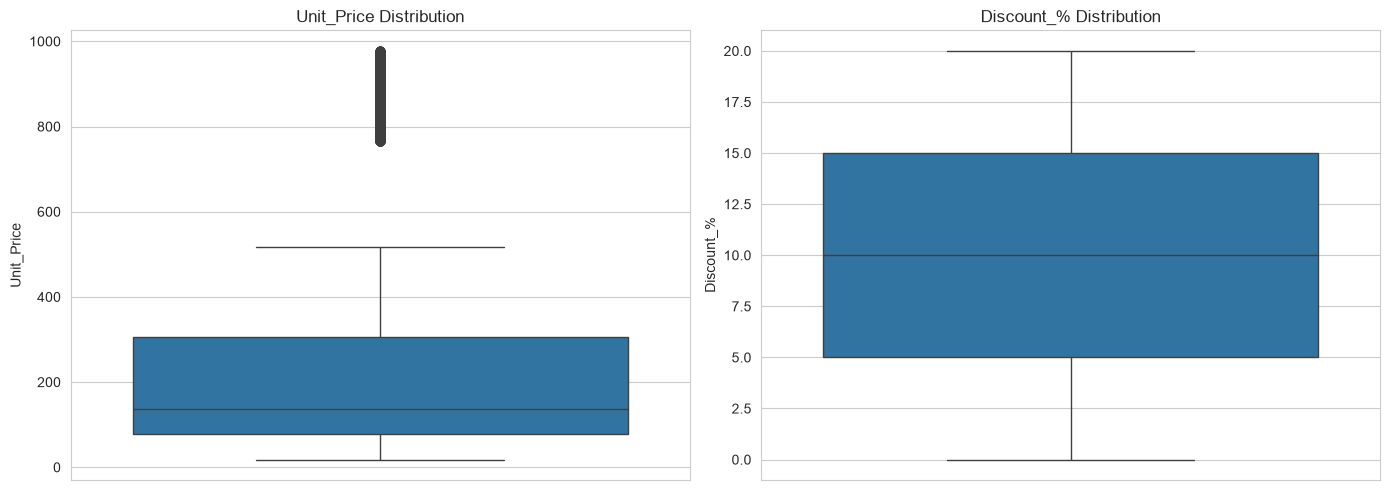

In [4]:
def detect_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper, outliers

for col in ['Unit_Price', 'Discount_%']:
    n, lo, hi, _ = detect_outliers_iqr(col)
    print(f"{col}: {n} outliers ({100*n/len(df):.1f}%) — bounds [{lo:.2f}, {hi:.2f}]")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['Unit_Price'], ax=axes[0])
axes[0].set_title('Unit_Price Distribution')
sns.boxplot(y=df['Discount_%'], ax=axes[1])
axes[1].set_title('Discount_% Distribution')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task1_outliers.png', dpi=100)
plt.show()


### 1c. Duplicate Order_IDs & Missing Values


In [5]:
dup_ids = df['Order_ID'].duplicated().sum()
print(f"Duplicate Order_IDs: {dup_ids}")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print(f"\nColumns with missing values:\n{missing}")
else:
    print("No missing values found in any column.")


Duplicate Order_IDs: 0
No missing values found in any column.


---
# Task 2: Time-Series Analysis


### 2a. Year-over-Year Comparison


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['YearMonth'] = df['Date'].dt.to_period('M')

yoy = df.groupby('Year')[['Revenue','Profit']].sum()
yoy['Revenue_Growth_%'] = yoy['Revenue'].pct_change() * 100
yoy['Profit_Growth_%'] = yoy['Profit'].pct_change() * 100
display(yoy)
print(f"\n2024 total revenue: ${yoy.loc[2024,'Revenue']:,.0f}")
print(f"2025 total revenue: ${yoy.loc[2025,'Revenue']:,.0f}")
print(f"2024 total profit: ${yoy.loc[2024,'Profit']:,.0f}")
print(f"2025 total profit: ${yoy.loc[2025,'Profit']:,.0f}")


,Revenue,Profit,Revenue_Growth_%,Profit_Growth_%
Year,,,,
2024,44265789.43,9166611.43,NaN,NaN
2025,43022520.90,8958904.90,-2.808644,-2.265903



2024 total revenue: $44,265,789
2025 total revenue: $43,022,521
2024 total profit: $9,166,611
2025 total profit: $8,958,905


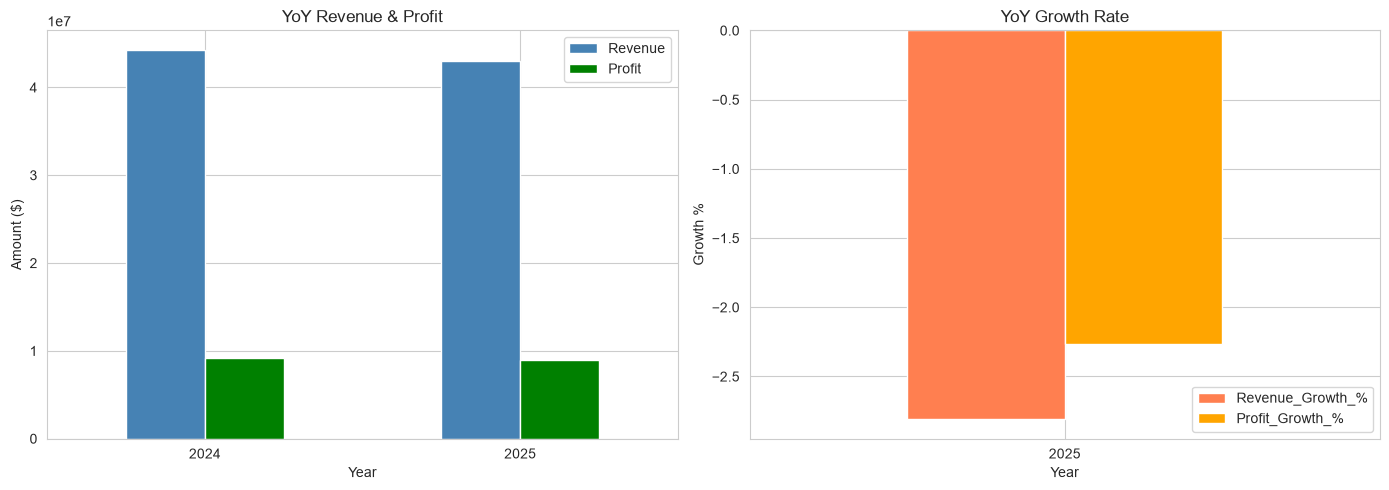

In [7]:
# YoY Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yoy[['Revenue','Profit']].plot(kind='bar', ax=axes[0], color=['steelblue','green'], edgecolor='white')
axes[0].set_title('YoY Revenue & Profit')
axes[0].set_ylabel('Amount ($)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

growth_df = yoy[['Revenue_Growth_%','Profit_Growth_%']].dropna()
growth_df.plot(kind='bar', ax=axes[1], color=['coral','orange'], edgecolor='white')
axes[1].set_title('YoY Growth Rate')
axes[1].set_ylabel('Growth %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task2_yoy_bar.png', dpi=100)
plt.show()


### 2b. Monthly & Quarterly Revenue/Profit Trends


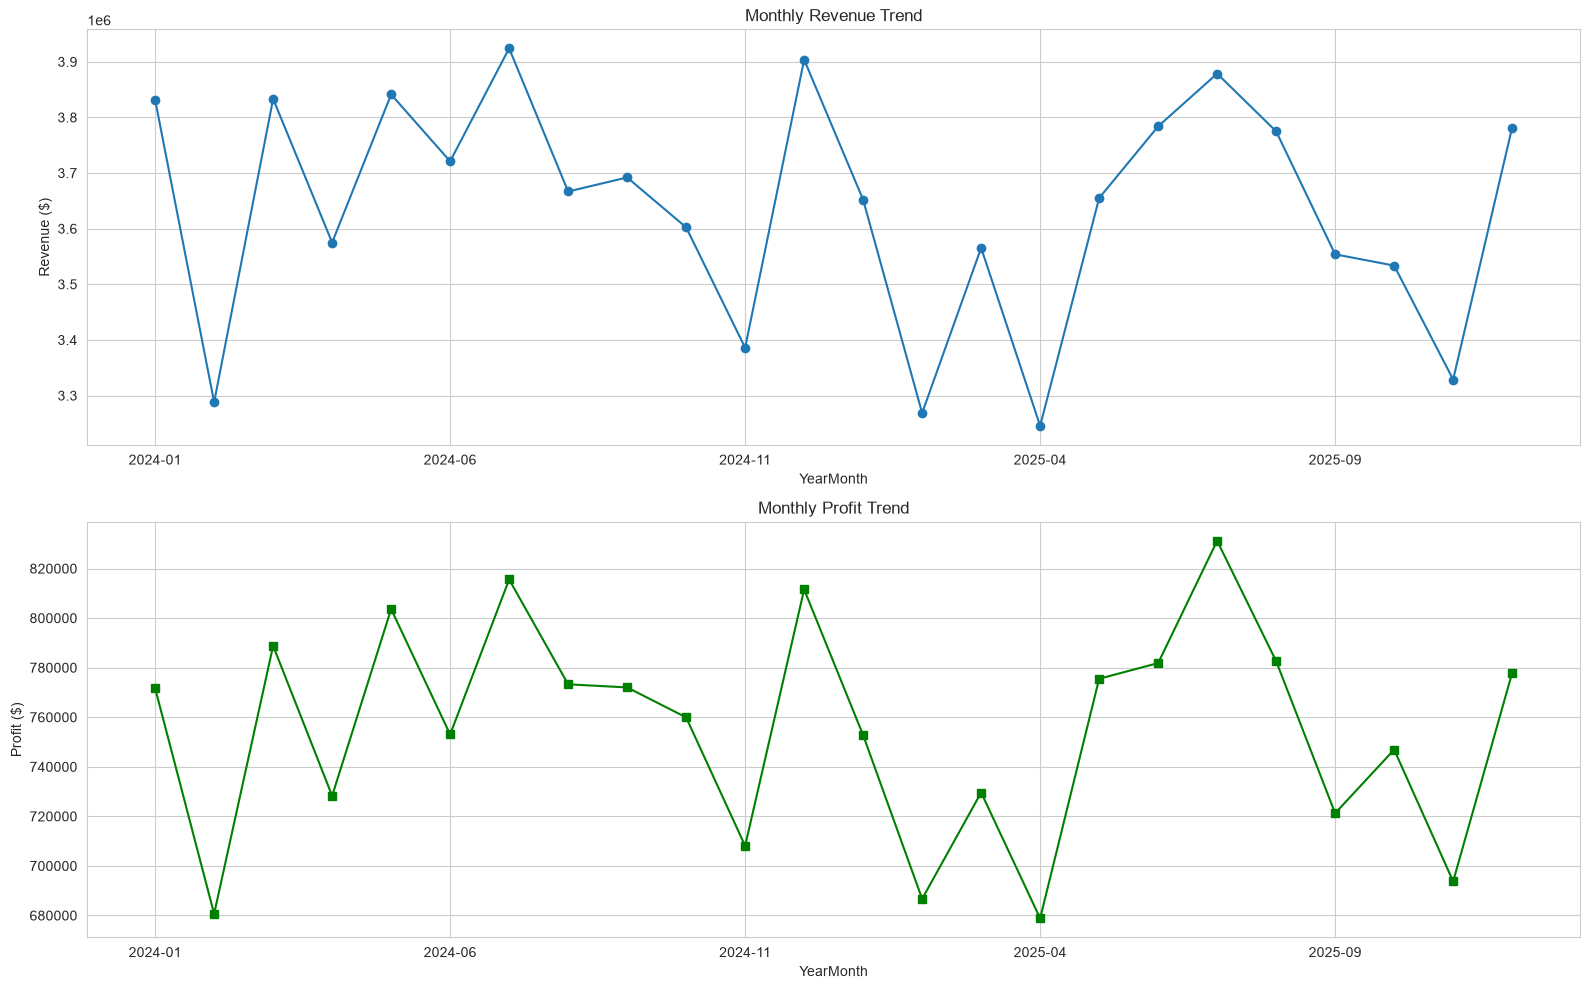

Revenue      Profit
Year Quarter                         
2024 1        10953112.52  2241168.52
     2        11137458.42  2284972.42
     3        11283078.83  2360896.83
     4        10892139.66  2279573.66
2025 1        10486093.44  2169083.44
     2        10684462.78  2236208.78
     3        11207601.09  2335051.09
     4        10644363.59  2218561.59

In [8]:
monthly = df.groupby('YearMonth')[['Revenue','Profit']].sum()
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
monthly['Revenue'].plot(ax=axes[0], marker='o', title='Monthly Revenue Trend')
axes[0].set_ylabel('Revenue ($)')
monthly['Profit'].plot(ax=axes[1], marker='s', color='green', title='Monthly Profit Trend')
axes[1].set_ylabel('Profit ($)')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task2_monthly_trends.png', dpi=100)
plt.show()

# Quarterly
quarterly = df.groupby(['Year','Quarter'])[['Revenue','Profit']].sum()
display(quarterly)


### 2c. Seasonality — Peak & Low Months


Peak revenue month: 7 (avg $1,826)
Low revenue month:  11 (avg $1,653)
Peak profit month:  7 (avg $385)
Low profit month:   4 (avg $341)


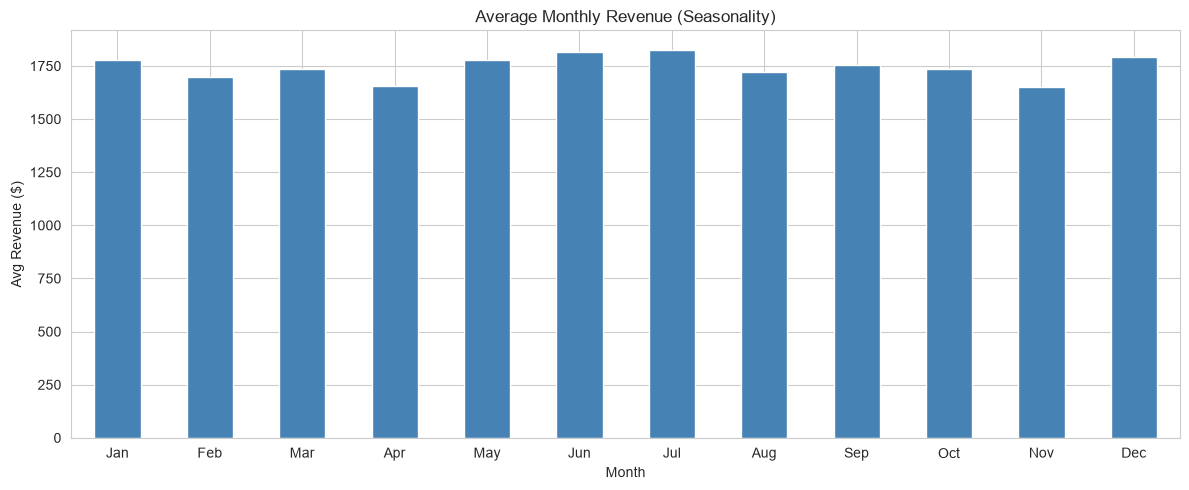

In [9]:
monthly_avg = df.groupby('Month')[['Revenue','Profit']].mean()
peak_rev = monthly_avg['Revenue'].idxmax()
low_rev = monthly_avg['Revenue'].idxmin()
peak_prof = monthly_avg['Profit'].idxmax()
low_prof = monthly_avg['Profit'].idxmin()
print(f"Peak revenue month: {peak_rev} (avg ${monthly_avg.loc[peak_rev,'Revenue']:,.0f})")
print(f"Low revenue month:  {low_rev} (avg ${monthly_avg.loc[low_rev,'Revenue']:,.0f})")
print(f"Peak profit month:  {peak_prof} (avg ${monthly_avg.loc[peak_prof,'Profit']:,.0f})")
print(f"Low profit month:   {low_prof} (avg ${monthly_avg.loc[low_prof,'Profit']:,.0f})")

fig, ax = plt.subplots(figsize=(12, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['Revenue'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_xticklabels(month_names, rotation=0)
ax.set_title('Average Monthly Revenue (Seasonality)')
ax.set_ylabel('Avg Revenue ($)')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task2_seasonality.png', dpi=100)
plt.show()


### 2d. YoY Growth by Region and Category


=== YoY Revenue Growth by Region ===


Year,2024,2025,YoY_Growth_%
Region,,,
Central,8906366.46,8772040.78,-1.508198
East,8744523.09,8505477.10,-2.733665
North,9206187.00,8443041.61,-8.289484
South,8518860.09,8677733.73,1.864964
West,8889852.79,8624227.68,-2.987958



=== YoY Revenue Growth by Category ===


Year,2024,2025,YoY_Growth_%
Category,,,
Accessories,2369658.42,2373731.83,0.171899
Electronics,28698057.77,27825428.53,-3.040726
Furniture,8026226.52,7699067.36,-4.076127
Networking,1850658.32,1805235.56,-2.454411
Office,3321188.40,3319057.62,-0.064157


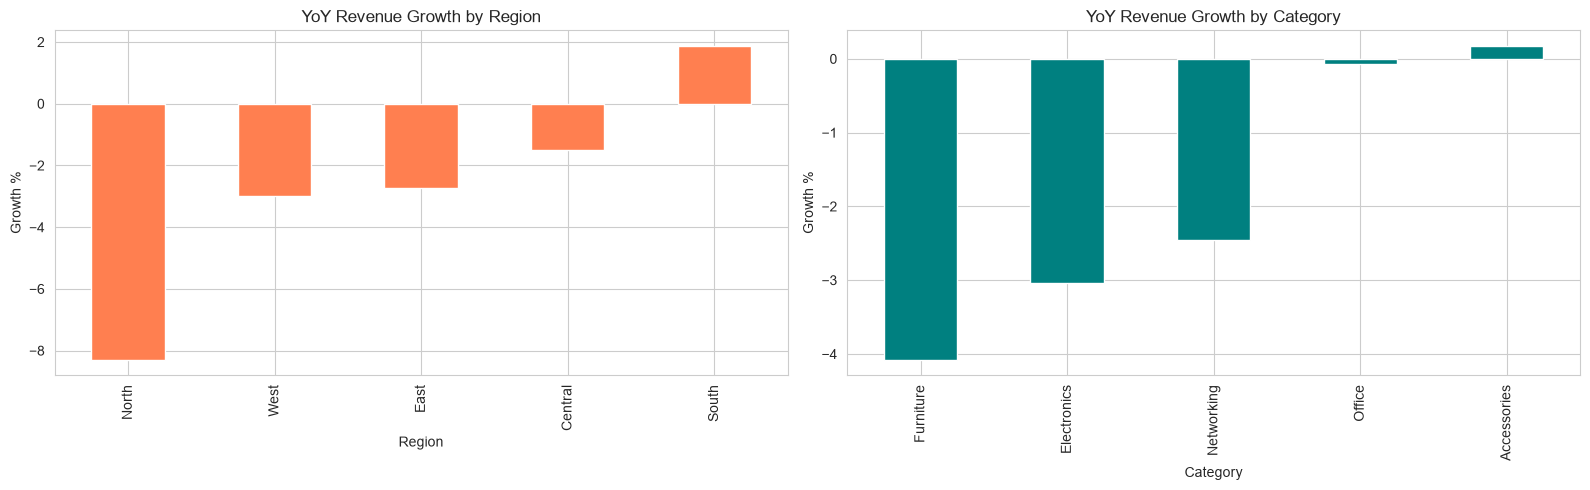

In [10]:
yoy_region = df.groupby(['Year','Region'])['Revenue'].sum().unstack(0)
yoy_region['YoY_Growth_%'] = ((yoy_region[2025] - yoy_region[2024]) / yoy_region[2024]) * 100
print("=== YoY Revenue Growth by Region ===")
display(yoy_region)

yoy_cat = df.groupby(['Year','Category'])['Revenue'].sum().unstack(0)
yoy_cat['YoY_Growth_%'] = ((yoy_cat[2025] - yoy_cat[2024]) / yoy_cat[2024]) * 100
print("\n=== YoY Revenue Growth by Category ===")
display(yoy_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
yoy_region['YoY_Growth_%'].sort_values().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('YoY Revenue Growth by Region')
axes[0].set_ylabel('Growth %')
yoy_cat['YoY_Growth_%'].sort_values().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('YoY Revenue Growth by Category')
axes[1].set_ylabel('Growth %')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task2_yoy_growth.png', dpi=100)
plt.show()


---
# Task 3: Profitability Analysis


### 3a. Profit Margin by Category, Product, and Region


=== Profit Margin by Category ===


,Profit_Margin_%
Category,
Office,14.804517
Electronics,18.110032
Furniture,23.301147
Networking,30.862792
Accessories,47.015408



=== Profit Margin by Product (Top/Bottom 5) ===


,Profit_Margin_%
Product,
Printer,14.804517
Laptop,16.099950
Tablet,17.197327
Desk,19.623247
Monitor,21.042513
Chair,27.017708
Router,30.862792
Headphones,41.564121
Keyboard,43.498837



=== Profit Margin by Region ===


,Profit_Margin_%
Region,
West,28.550660
East,28.632569
North,28.823608
Central,28.918710
South,28.929721


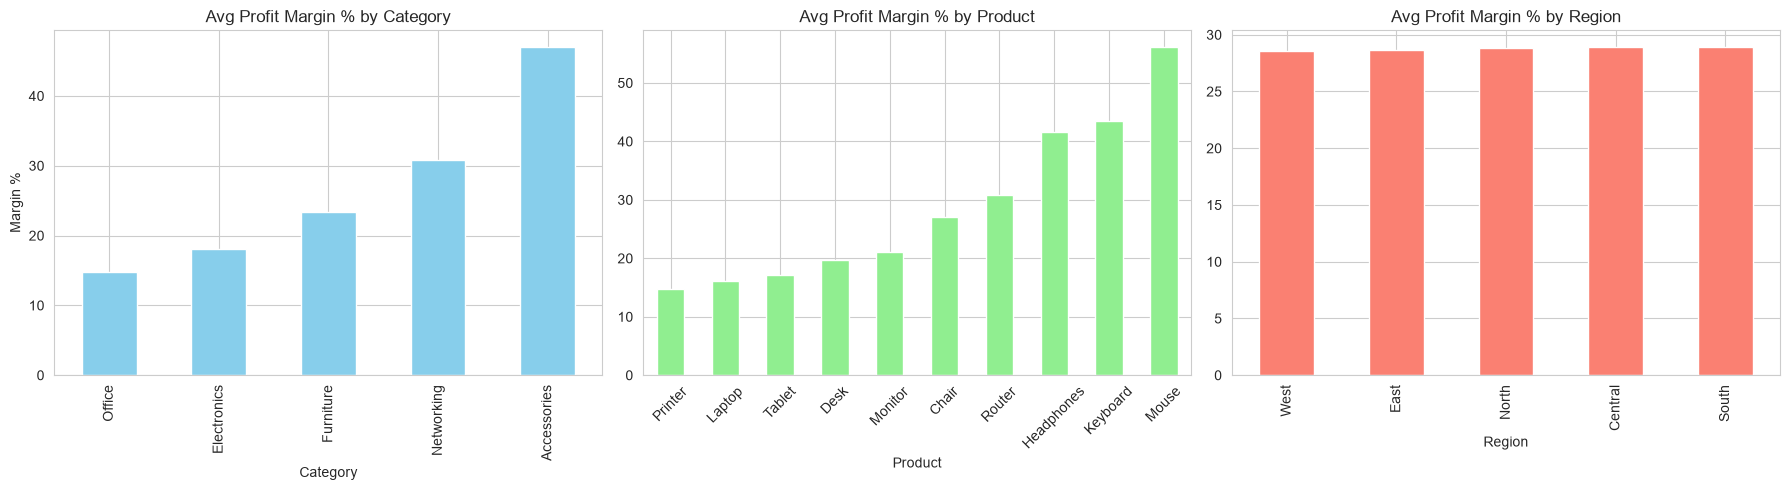

In [11]:
df['Profit_Margin_%'] = (df['Profit'] / df['Revenue']) * 100

# By Category
cat_margin = df.groupby('Category')['Profit_Margin_%'].mean().sort_values()
print("=== Profit Margin by Category ===")
display(cat_margin.to_frame())

# By Product
prod_margin = df.groupby('Product')['Profit_Margin_%'].mean().sort_values()
print("\n=== Profit Margin by Product (Top/Bottom 5) ===")
display(prod_margin.to_frame())

# By Region
reg_margin = df.groupby('Region')['Profit_Margin_%'].mean().sort_values()
print("\n=== Profit Margin by Region ===")
display(reg_margin.to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cat_margin.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Avg Profit Margin % by Category')
axes[0].set_ylabel('Margin %')
prod_margin.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Avg Profit Margin % by Product')
axes[1].tick_params(axis='x', rotation=45)
reg_margin.plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Avg Profit Margin % by Region')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_profit_margins.png', dpi=100)
plt.show()


### 3b. Negative Profit Orders — Common Patterns


Orders with negative profit: 826 (1.7% of total)
Total loss from negative orders: $-60,094


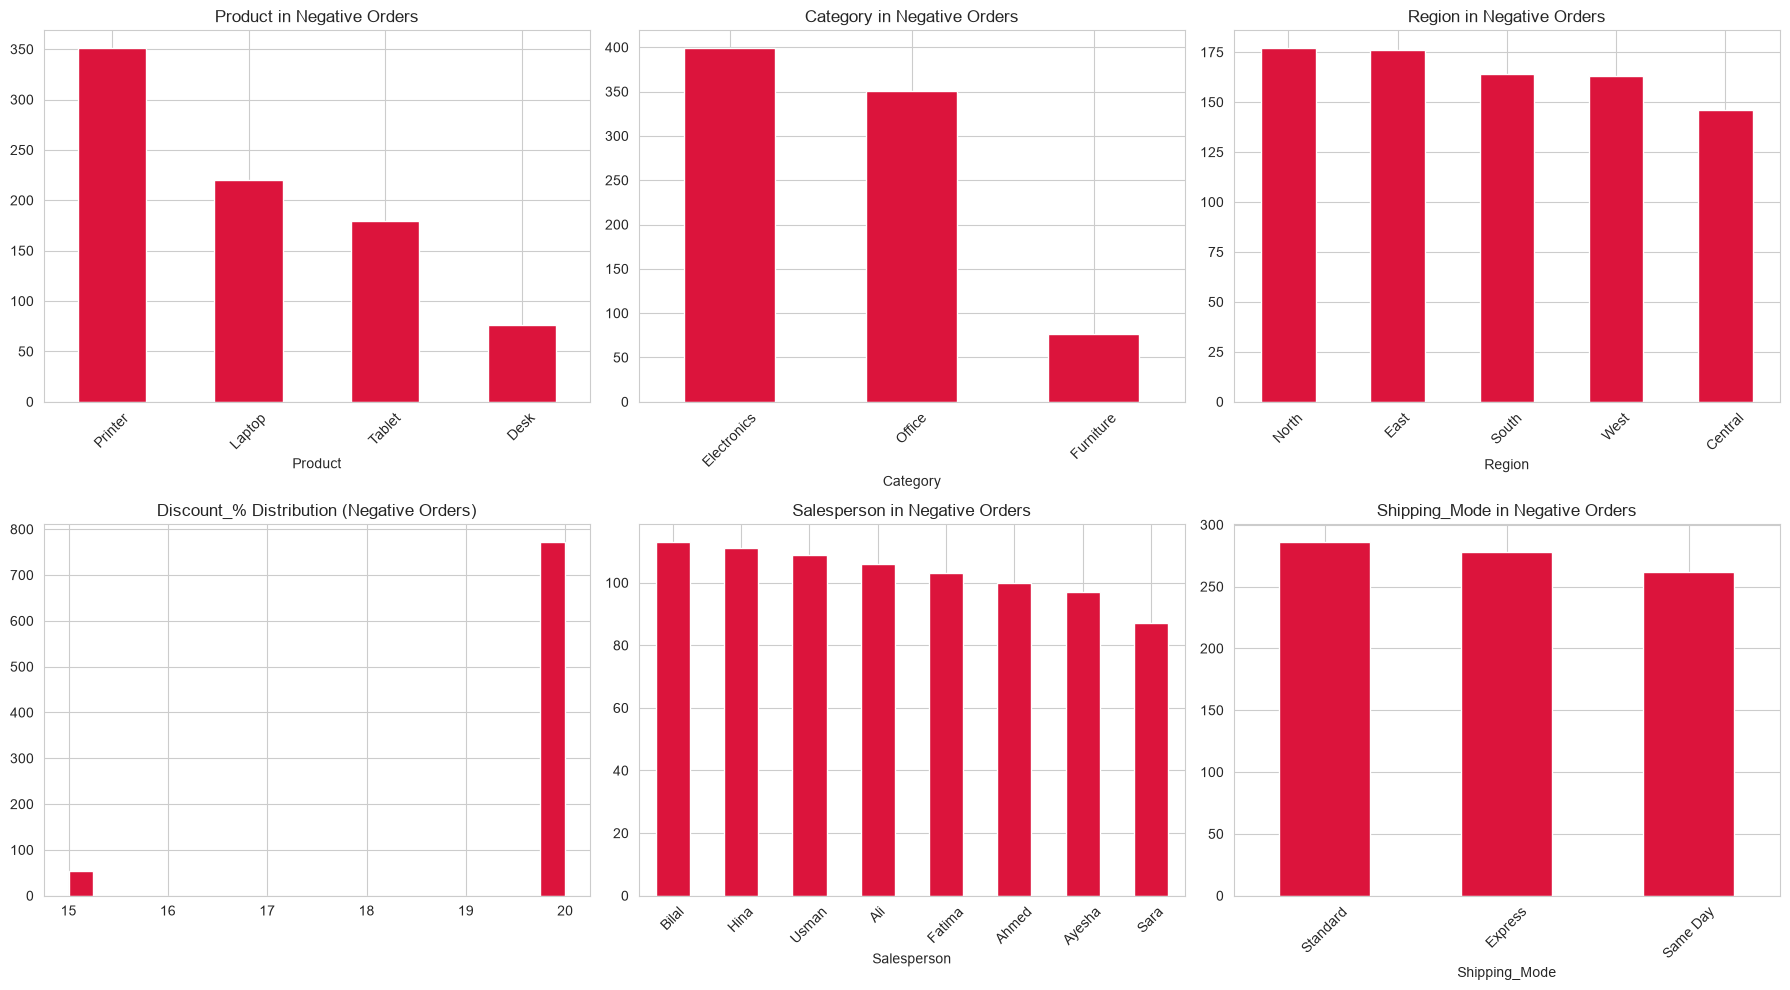

Average discount on negative orders: 19.7%
Average discount on profitable orders: 9.8%

Top products by negative order count:


,count
Product,
Printer,351
Laptop,220
Tablet,179
Desk,76



Top regions by negative order count:


,count
Region,
North,177
East,176
South,164
West,163
Central,146


In [12]:
neg = df[df['Profit'] < 0].copy()
print(f"Orders with negative profit: {len(neg)} ({100*len(neg)/len(df):.1f}% of total)")
print(f"Total loss from negative orders: ${neg['Profit'].sum():,.0f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(['Product','Category','Region','Discount_%','Salesperson','Shipping_Mode']):
    ax = axes[i//3][i%3]
    if col == 'Discount_%':
        neg[col].hist(ax=ax, bins=20, color='crimson', edgecolor='white')
        ax.set_title(f'{col} Distribution (Negative Orders)')
    else:
        neg[col].value_counts().head(10).plot(kind='bar', ax=ax, color='crimson')
        ax.set_title(f'{col} in Negative Orders')
        ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_negative_orders.png', dpi=100)
plt.show()

# Summary of patterns
print(f"Average discount on negative orders: {neg['Discount_%'].mean():.1f}%")
print(f"Average discount on profitable orders: {df[df['Profit']>=0]['Discount_%'].mean():.1f}%")
print(f"\nTop products by negative order count:")
display(neg['Product'].value_counts().head(5).to_frame())
print(f"\nTop regions by negative order count:")
display(neg['Region'].value_counts().head(5).to_frame())


### 3c. Correlation: Discount_% vs Profit Margin


Correlation between Discount_% and Profit Margin: -0.3649


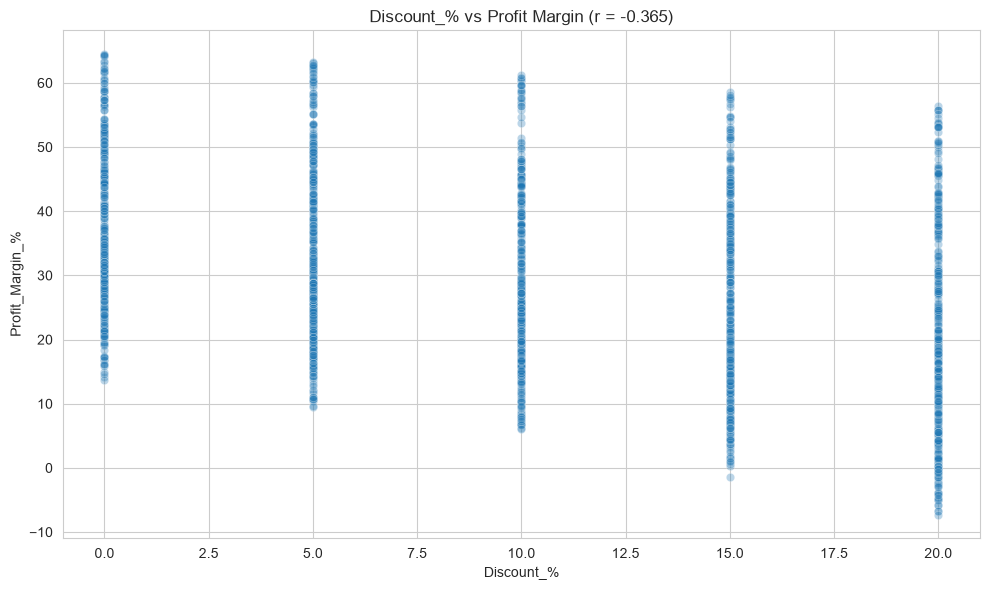

In [13]:
corr = df['Discount_%'].corr(df['Profit_Margin_%'])
print(f"Correlation between Discount_% and Profit Margin: {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x='Discount_%', y='Profit_Margin_%', alpha=0.3, ax=ax)
ax.set_title(f'Discount_% vs Profit Margin (r = {corr:.3f})')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task3_discount_correlation.png', dpi=100)
plt.show()


---
# Task 4: Customer Analysis


### 4a. RFM Analysis (Recency, Frequency, Monetary)


In [14]:
ref_date = df['Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer_ID').agg(
    Recency=('Date', lambda x: (ref_date - x.max()).days),
    Frequency=('Order_ID', 'count'),
    Monetary=('Revenue', 'sum')
).reset_index()

# RFM scores (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

print(f"Total unique customers: {len(rfm)}")
display(rfm.describe())
print(f"\nTop 10 customers by RFM Score:")
display(rfm.sort_values('RFM_Score', ascending=False).head(10))


Total unique customers: 2000


,Recency,Frequency,Monetary,RFM_Score
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,29.628000,25.000000,43644.155165,9.035500
std,29.328394,5.011143,14153.093376,3.024535
min,1.000000,10.000000,6541.220000,3.000000
25%,9.000000,22.000000,33502.837500,7.000000
50%,21.000000,25.000000,42355.150000,9.000000
75%,40.000000,28.000000,52401.912500,11.000000
max,207.000000,45.000000,103143.590000,15.000000



Top 10 customers by RFM Score:


,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
519,CUST1519,1,34,61078.93,5,5,5,15
1828,CUST2828,5,35,75357.30,5,5,5,15
469,CUST1469,1,33,62541.62,5,5,5,15
63,CUST1063,1,30,64013.46,5,5,5,15
590,CUST1590,2,30,58917.50,5,5,5,15
566,CUST1566,1,36,57215.28,5,5,5,15
1824,CUST2824,4,33,58319.36,5,5,5,15
1477,CUST2477,4,32,62339.59,5,5,5,15
676,CUST1676,7,30,80823.08,5,5,5,15
1858,CUST2858,5,38,72041.58,5,5,5,15


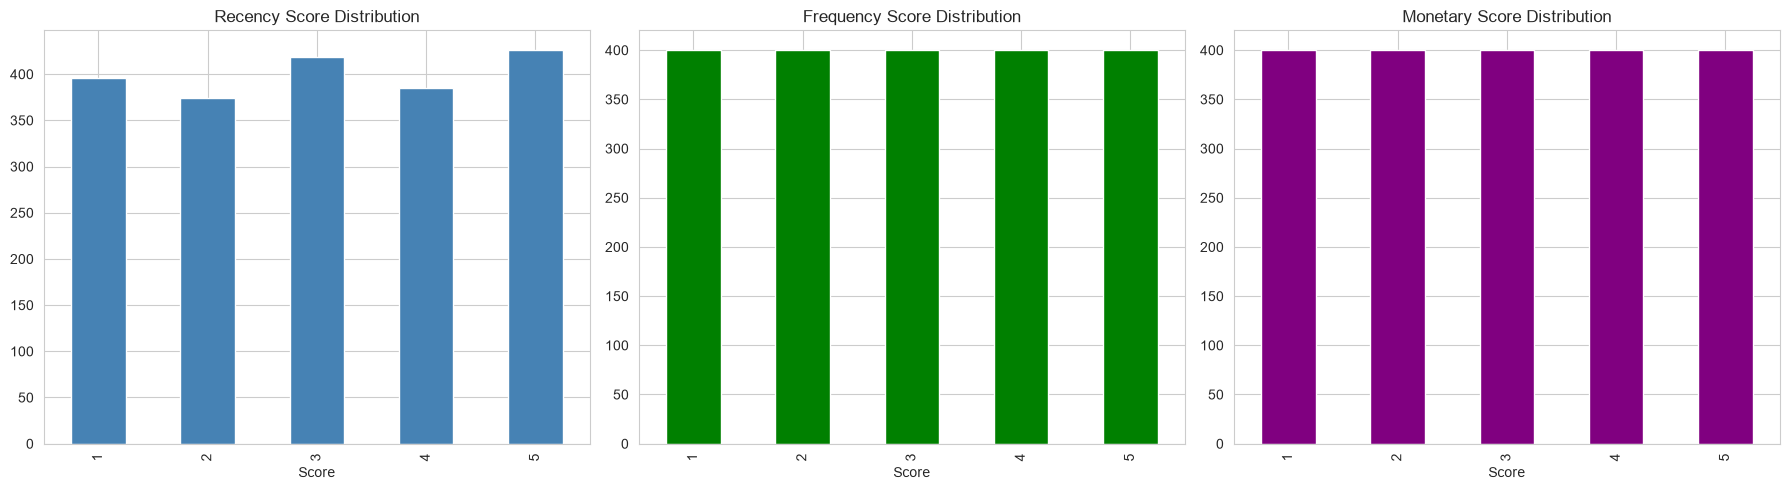

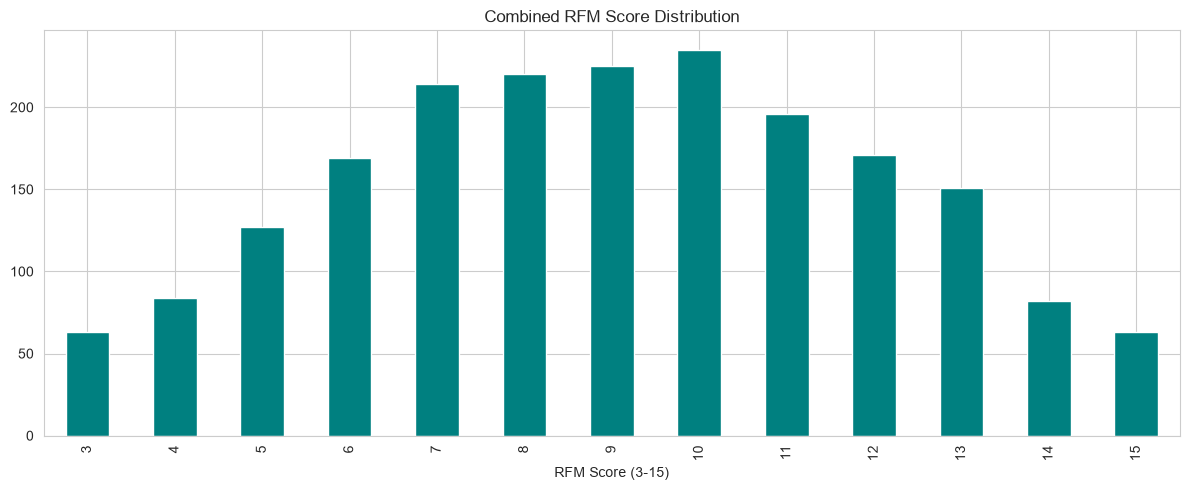

In [15]:
# RFM Score Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rfm['R_Score'].astype(int).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Recency Score Distribution')
axes[0].set_xlabel('Score')
rfm['F_Score'].astype(int).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Frequency Score Distribution')
axes[1].set_xlabel('Score')
rfm['M_Score'].astype(int).value_counts().sort_index().plot(kind='bar', ax=axes[2], color='purple')
axes[2].set_title('Monetary Score Distribution')
axes[2].set_xlabel('Score')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task4_rfm_distribution.png', dpi=100)
plt.show()

# RFM Combined Score
fig, ax = plt.subplots(figsize=(12, 5))
rfm['RFM_Score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='teal')
ax.set_title('Combined RFM Score Distribution')
ax.set_xlabel('RFM Score (3-15)')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task4_rfm_combined.png', dpi=100)
plt.show()


### 4b. Pareto Analysis — Top 20% of Customers


Top 20% of customers represent 29.5% of total revenue
Bottom 69.3% of customers generate 80% of revenue (Pareto check)


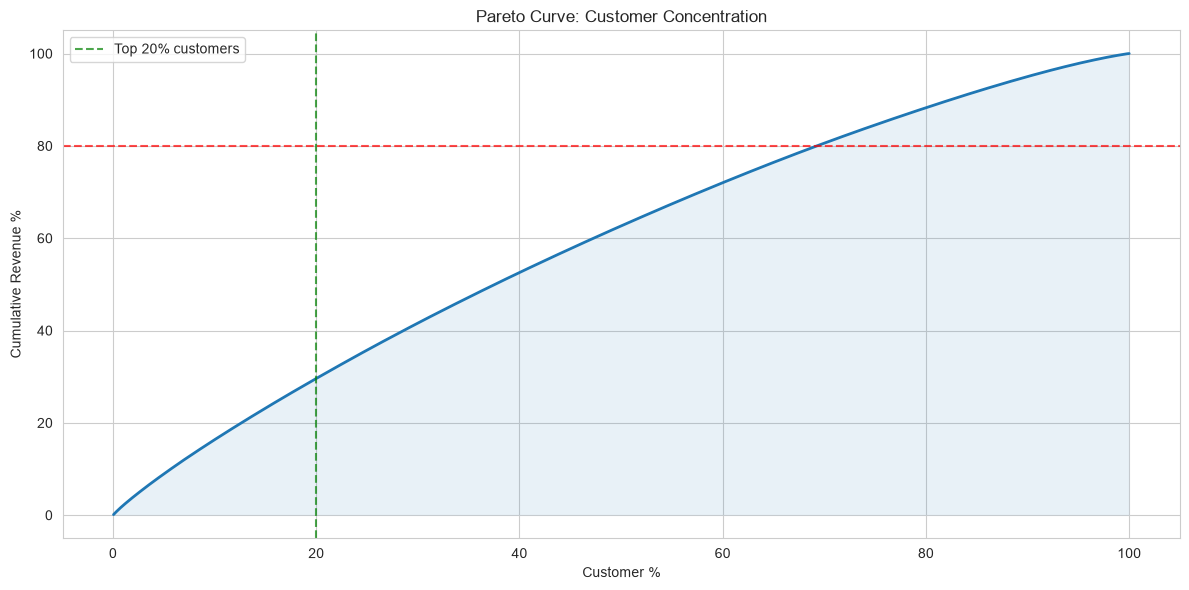

In [16]:
rfm_sorted = rfm.sort_values('Monetary', ascending=False)
rfm_sorted['Cum_Revenue'] = rfm_sorted['Monetary'].cumsum()
total_rev = rfm_sorted['Monetary'].sum()
rfm_sorted['Cum_Revenue_Pct'] = rfm_sorted['Cum_Revenue'] / total_rev * 100
rfm_sorted['Cust_Pct'] = (np.arange(1, len(rfm_sorted)+1) / len(rfm_sorted)) * 100

# Find top 20%
top20_pct = 20
top20_cutoff = np.searchsorted(rfm_sorted['Cust_Pct'], top20_pct)
top20_rev_pct = rfm_sorted.iloc[top20_cutoff-1]['Cum_Revenue_Pct']
print(f"Top {top20_pct}% of customers represent {top20_rev_pct:.1f}% of total revenue")

# Find % needed for 80% revenue
pct_80 = np.searchsorted(rfm_sorted['Cum_Revenue_Pct'], 80)
cust_pct_80 = rfm_sorted.iloc[pct_80]['Cust_Pct']
print(f"Bottom {cust_pct_80:.1f}% of customers generate 80% of revenue (Pareto check)")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rfm_sorted['Cust_Pct'], rfm_sorted['Cum_Revenue_Pct'], linewidth=2)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=20, color='green', linestyle='--', alpha=0.7, label='Top 20% customers')
ax.fill_between(rfm_sorted['Cust_Pct'], rfm_sorted['Cum_Revenue_Pct'], alpha=0.1)
ax.set_xlabel('Customer %')
ax.set_ylabel('Cumulative Revenue %')
ax.set_title('Pareto Curve: Customer Concentration')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task4_pareto.png', dpi=100)
plt.show()


### 4c. Customer_Rating vs Returned Orders


=== Return Rate by Customer Rating ===


,Returned
Customer_Rating,
1,24.805661
2,25.645194
3,24.684915
4,24.839034
5,24.720782



Correlation (Customer_Rating vs Returned): -0.0032


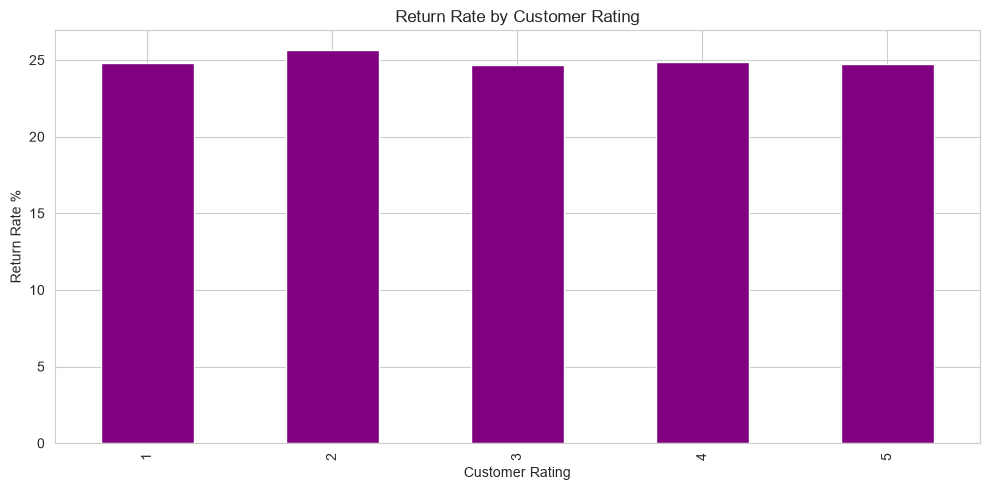

In [17]:
rating_return = df.groupby('Customer_Rating')['Returned'].mean() * 100
print("=== Return Rate by Customer Rating ===")
display(rating_return.to_frame())

rating_corr = df['Customer_Rating'].corr(df['Returned'])
print(f"\nCorrelation (Customer_Rating vs Returned): {rating_corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
rating_return.plot(kind='bar', ax=ax, color='purple')
ax.set_title('Return Rate by Customer Rating')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Return Rate %')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task4_rating_vs_return.png', dpi=100)
plt.show()


---
# Task 5: Returns Analysis


### 5a. Overall Return Rate


In [18]:
overall_return_rate = df['Returned'].mean() * 100
print(f"Overall return rate: {overall_return_rate:.2f}%")
print(f"Returned orders: {df['Returned'].sum()} / {len(df)}")


Overall return rate: 24.94%
Returned orders: 12468 / 50000


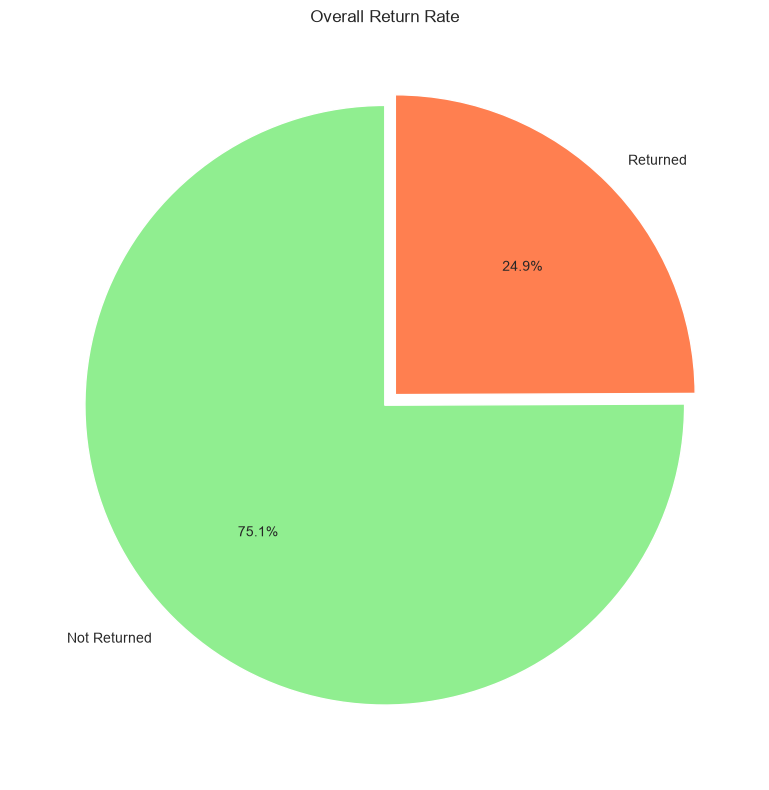

In [19]:
# Return Rate Pie Chart
fig, ax = plt.subplots(figsize=(8, 8))
return_counts = df['Returned'].value_counts()
labels = ['Not Returned', 'Returned']
colors = ['lightgreen', 'coral']
ax.pie(return_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
ax.set_title('Overall Return Rate')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task5_return_pie.png', dpi=100)
plt.show()


### 5b. Return Rate by Product, Category, Region, Salesperson, Shipping_Mode


=== Return Rate by Product ===


,Returned
Product,
Printer,24.151172
Chair,24.157081
Mouse,24.381770
Laptop,24.702321
Tablet,24.732485
Headphones,24.984778
Keyboard,24.995091
Monitor,25.354394
Router,25.698216


=== Return Rate by Category ===


,Returned
Category,
Office,24.151172
Accessories,24.790451
Electronics,24.929274
Furniture,25.155371
Networking,25.698216


=== Return Rate by Region ===


,Returned
Region,
Central,24.132805
South,24.654793
North,25.208831
East,25.334686
West,25.360000


=== Return Rate by Salesperson ===


,Returned
Salesperson,
Bilal,24.228444
Ayesha,24.462279
Ali,24.481595
Hina,24.778761
Fatima,24.906822
Sara,25.111465
Usman,25.526191
Ahmed,25.979611


=== Return Rate by Shipping_Mode ===


,Returned
Shipping_Mode,
Express,24.700355
Same Day,24.867567
Standard,25.241022


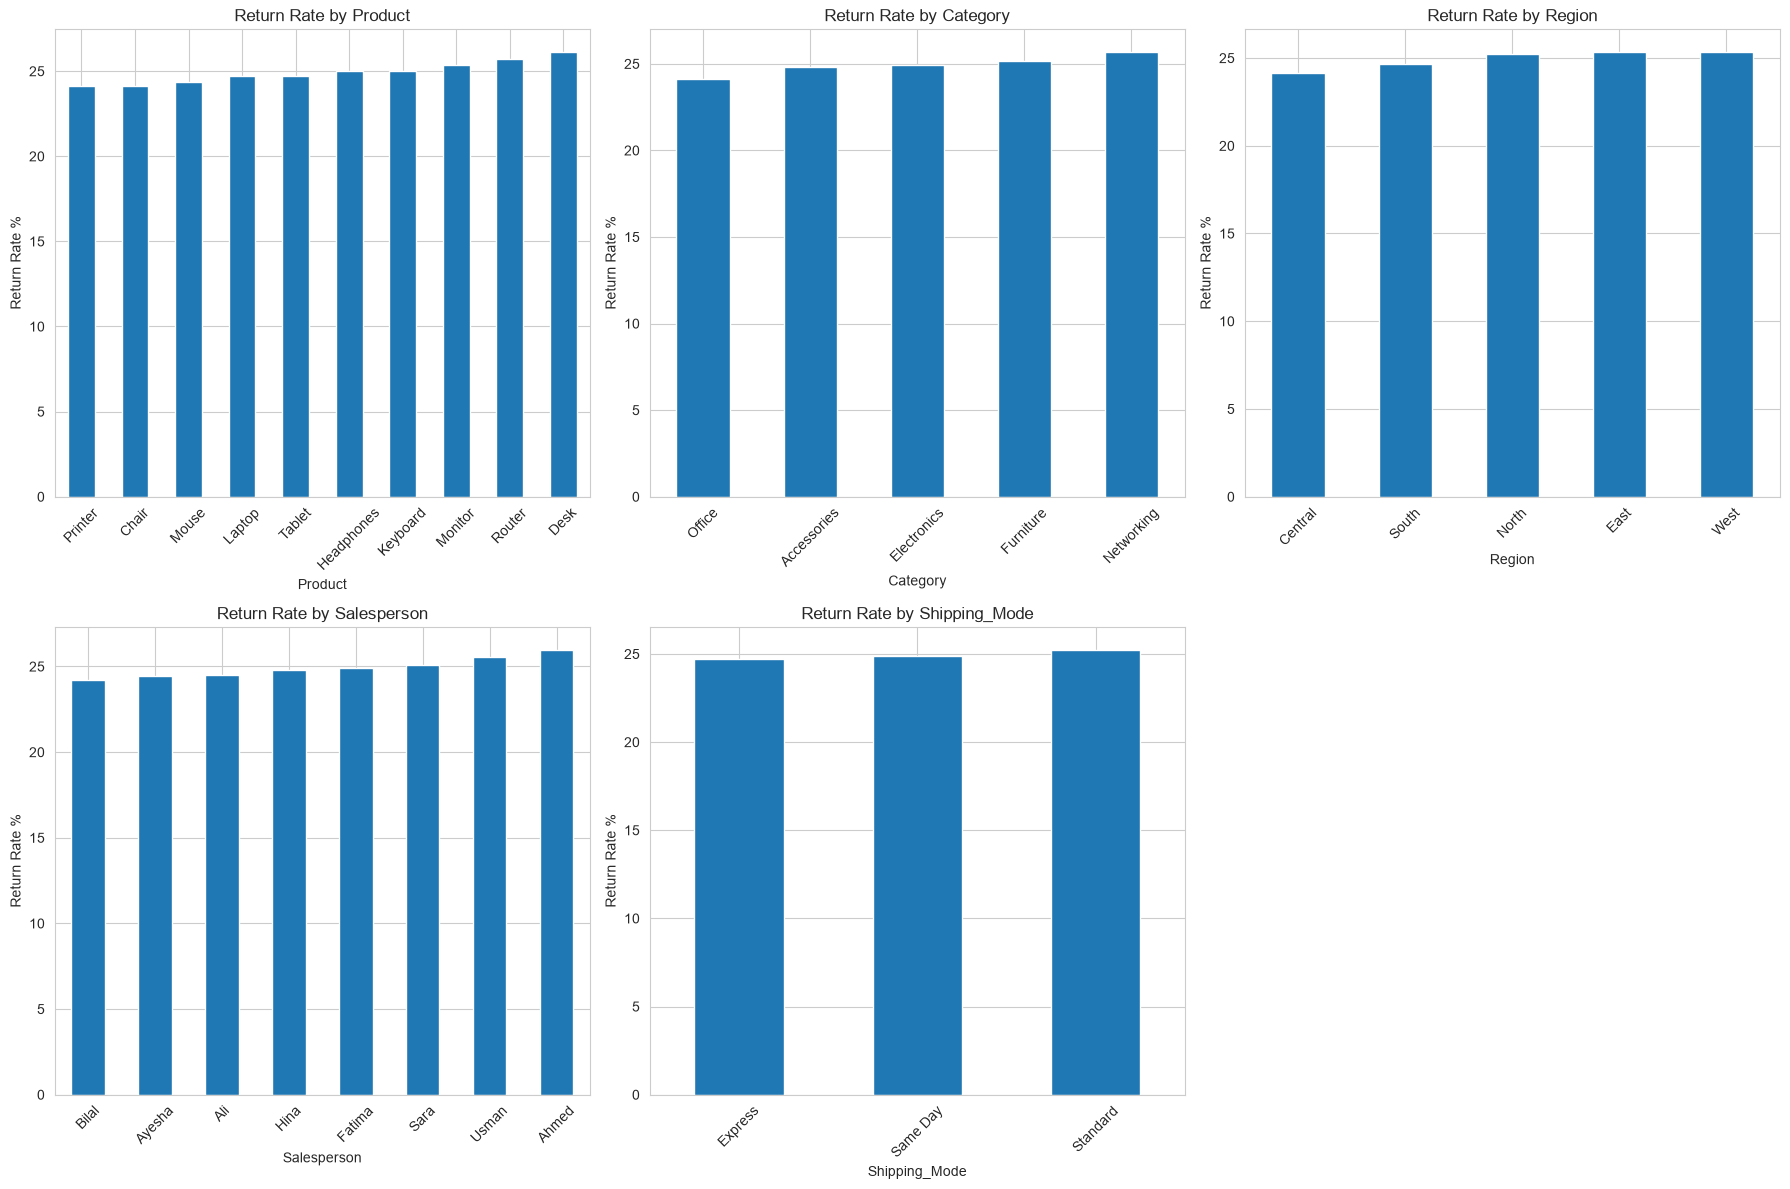

In [20]:
breakdown_cols = ['Product','Category','Region','Salesperson','Shipping_Mode']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()
for i, col in enumerate(breakdown_cols):
    ax = axes_flat[i]
    rate = df.groupby(col)['Returned'].mean().sort_values() * 100
    rate.plot(kind='bar', ax=ax)
    ax.set_title(f'Return Rate by {col}')
    ax.set_ylabel('Return Rate %')
    ax.tick_params(axis='x', rotation=45)
    print(f"=== Return Rate by {col} ===")
    display(rate.to_frame())
axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task5_return_breakdowns.png', dpi=100)
plt.show()


### 5c. Same Day Shipping vs Others Return Rate


In [21]:
ship_return = df.groupby('Shipping_Mode')['Returned'].mean() * 100
print("=== Return Rate by Shipping Mode ===")
display(ship_return.to_frame())
same_day = ship_return.get('Same Day', 0)
standard = ship_return.get('Standard', 0)
express = ship_return.get('Express', 0)
print(f"\nSame Day: {same_day:.2f}%")
print(f"Standard: {standard:.2f}%")
print(f"Express: {express:.2f}%")
if same_day > max(standard, express):
    print("[WARN] Same Day shipping has HIGHER return rate than Standard/Express")
elif same_day < min(standard, express):
    print("[OK] Same Day shipping has LOWER return rate than Standard/Express")
else:
    print("Same Day shipping return rate is between Standard and Express.")


=== Return Rate by Shipping Mode ===


,Returned
Shipping_Mode,
Express,24.700355
Same Day,24.867567
Standard,25.241022



Same Day: 24.87%
Standard: 25.24%
Express: 24.70%
Same Day shipping return rate is between Standard and Express.


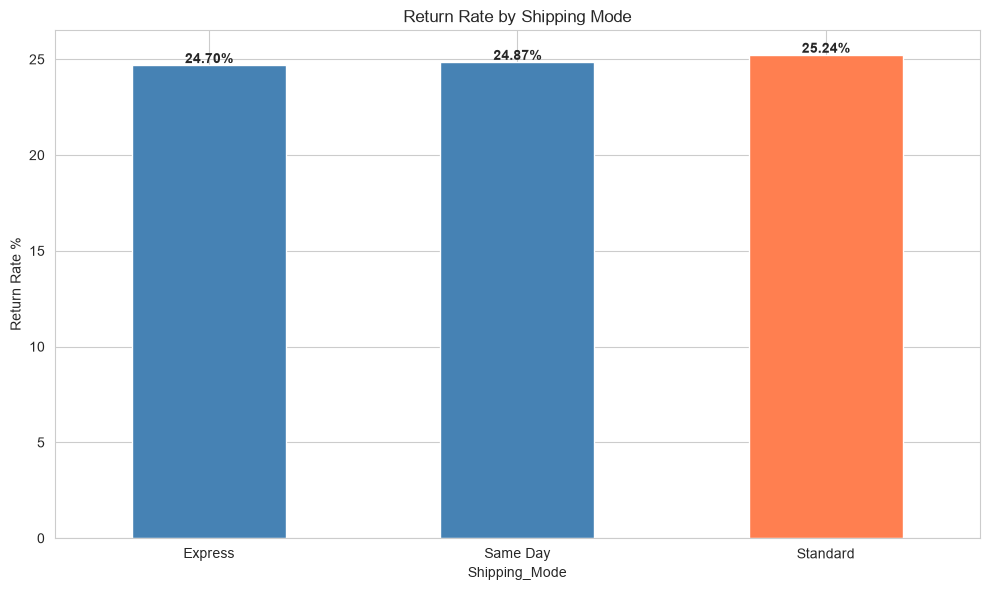

In [22]:
# Shipping Mode Return Rate Chart
fig, ax = plt.subplots(figsize=(10, 6))
ship_return_sorted = ship_return.sort_values()
colors_bar = ['coral' if x == ship_return_sorted.max() else 'steelblue' for x in ship_return_sorted.values]
ship_return_sorted.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Return Rate by Shipping Mode')
ax.set_ylabel('Return Rate %')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(ship_return_sorted.values):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task5_shipping_return_rate.png', dpi=100)
plt.show()


### 5d. Revenue & Profit Lost to Returns


In [23]:
returns = df[df['Returned'] == 1]
non_returns = df[df['Returned'] == 0]
rev_lost = returns['Revenue'].sum()
profit_lost = returns['Profit'].sum()
print(f"Revenue lost to returns: ${rev_lost:,.0f} ({100*rev_lost/df['Revenue'].sum():.1f}% of total)")
print(f"Profit lost to returns: ${profit_lost:,.0f} ({100*profit_lost/df['Profit'].sum():.1f}% of total)")
print(f"Avg revenue per returned order: ${returns['Revenue'].mean():,.0f}")
print(f"Avg revenue per non-returned order: ${non_returns['Revenue'].mean():,.0f}")


Revenue lost to returns: $21,668,284 (24.8% of total)
Profit lost to returns: $4,484,658 (24.7% of total)
Avg revenue per returned order: $1,738
Avg revenue per non-returned order: $1,748


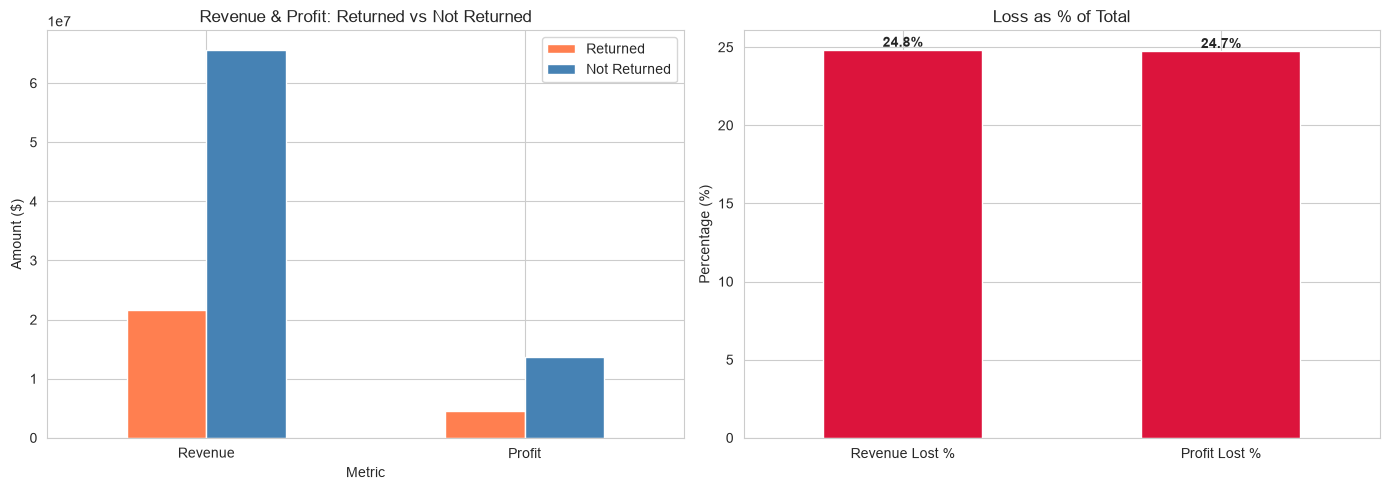

In [24]:
# Revenue & Profit Lost to Returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loss_data = pd.DataFrame({
    'Metric': ['Revenue', 'Profit'],
    'Returned': [rev_lost, profit_lost],
    'Not Returned': [non_returns['Revenue'].sum(), non_returns['Profit'].sum()]
}).set_index('Metric')
loss_data.plot(kind='bar', ax=axes[0], color=['coral', 'steelblue'], edgecolor='white')
axes[0].set_title('Revenue & Profit: Returned vs Not Returned')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

loss_pct = pd.Series({
    'Revenue Lost %': 100 * rev_lost / df['Revenue'].sum(),
    'Profit Lost %': 100 * profit_lost / df['Profit'].sum()
})
loss_pct.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Loss as % of Total')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(loss_pct.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task5_return_loss.png', dpi=100)
plt.show()


---
# Task 6: Payment & Shipping Behavior


### 6a. Revenue & Profit by Payment Method


=== Revenue & Profit by Payment Method ===


,Revenue,Profit,Order_Count,Revenue_%,Profit_%
Payment_Method,,,,,
Bank Transfer,21861983.37,4540167.37,12410,25.045717,25.048486
Card,21868286.12,4533352.12,12583,25.052938,25.010885
Cash,21726689.71,4551147.71,12534,24.890721,25.109065
Online Wallet,21831351.13,4500849.13,12473,25.010624,24.831564


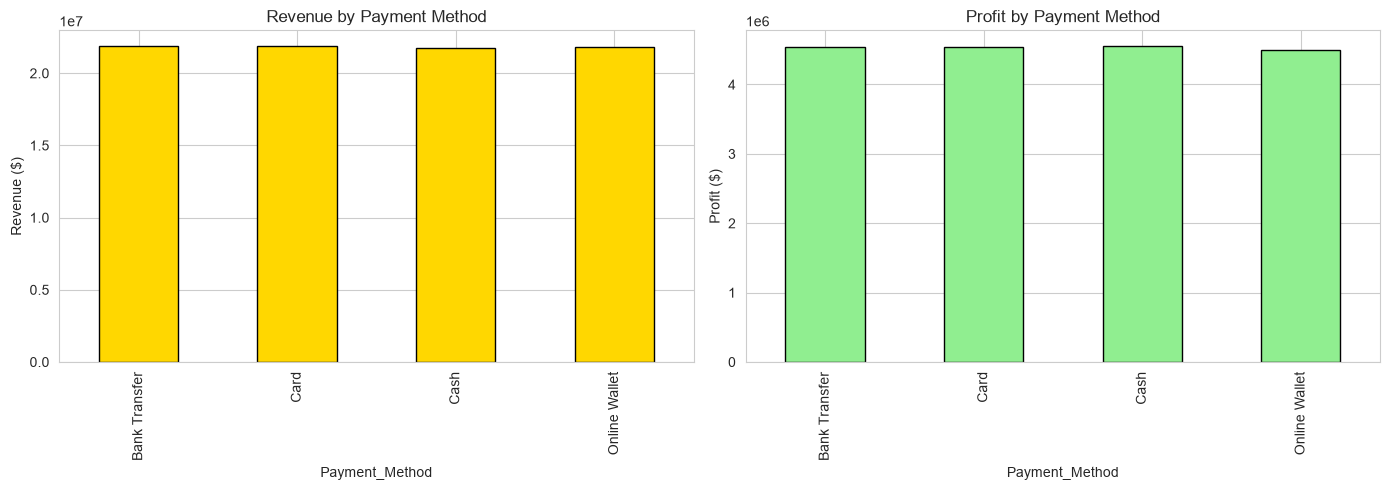

In [25]:
pmt = df.groupby('Payment_Method')[['Revenue','Profit']].sum()
pmt['Order_Count'] = df.groupby('Payment_Method').size()
pmt['Revenue_%'] = pmt['Revenue'] / pmt['Revenue'].sum() * 100
pmt['Profit_%'] = pmt['Profit'] / pmt['Profit'].sum() * 100
print("=== Revenue & Profit by Payment Method ===")
display(pmt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pmt['Revenue'].plot(kind='bar', ax=axes[0], color='gold', edgecolor='black')
axes[0].set_title('Revenue by Payment Method')
axes[0].set_ylabel('Revenue ($)')
pmt['Profit'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Profit by Payment Method')
axes[1].set_ylabel('Profit ($)')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task6_payment_methods.png', dpi=100)
plt.show()


### 6b. Shipping Mode Preference by Region and Category


=== Shipping Mode % by Region ===


Shipping_Mode,Express,Same Day,Standard
Region,,,
Central,32.784936,33.845391,33.369673
East,33.133874,34.137931,32.728195
North,33.144391,33.422832,33.432776
South,33.570142,33.229938,33.199920
West,33.400000,33.380000,33.220000



=== Shipping Mode % by Category ===


Shipping_Mode,Express,Same Day,Standard
Category,,,
Accessories,33.333333,33.373567,33.293100
Electronics,33.032467,34.076519,32.891014
Furniture,33.362928,33.353063,33.284009
Networking,32.835531,33.785881,33.378588
Office,33.407437,33.185125,33.407437


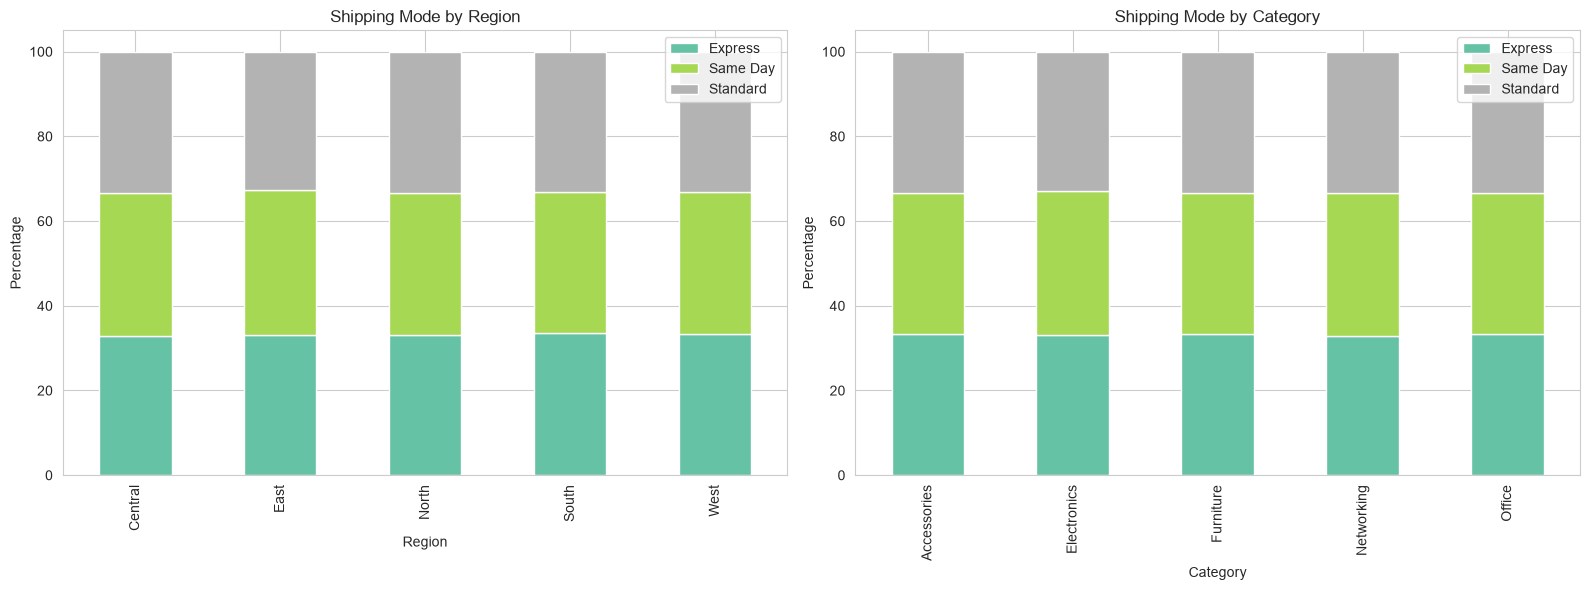

In [26]:
shipping_region = pd.crosstab(df['Region'], df['Shipping_Mode'], normalize='index') * 100
print("=== Shipping Mode % by Region ===")
display(shipping_region)

shipping_cat = pd.crosstab(df['Category'], df['Shipping_Mode'], normalize='index') * 100
print("\n=== Shipping Mode % by Category ===")
display(shipping_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shipping_region.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Shipping Mode by Region')
axes[0].set_ylabel('Percentage')
axes[0].legend(loc='upper right')
shipping_cat.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Shipping Mode by Category')
axes[1].set_ylabel('Percentage')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task6_shipping_preferences.png', dpi=100)
plt.show()


### 6c. Does Shipping Mode Affect Customer Rating?


=== Avg Customer Rating by Shipping Mode ===


,Customer_Rating
Shipping_Mode,
Express,3.020538
Same Day,3.002440
Standard,2.982164



ANOVA test: F=3.058, p=0.046988
Significant difference in ratings across shipping modes (p < 0.05)


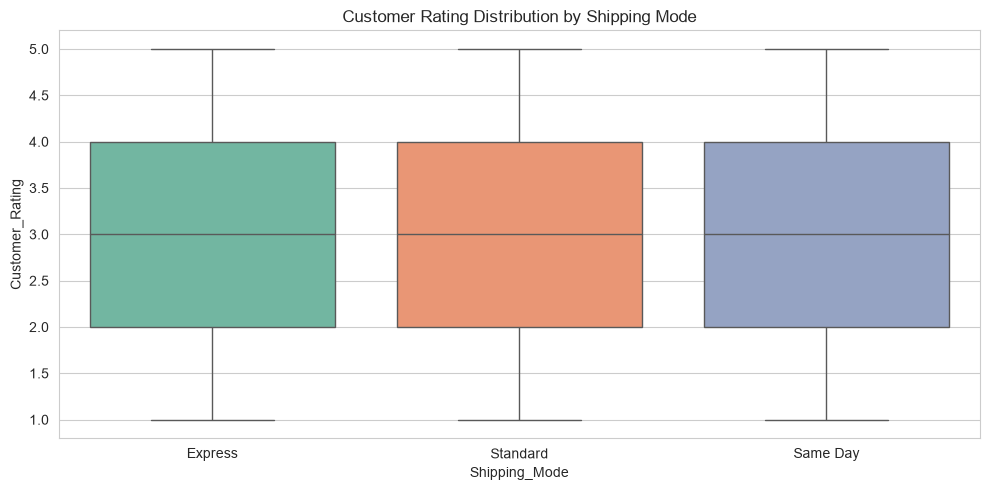

In [27]:
ship_rating = df.groupby('Shipping_Mode')['Customer_Rating'].mean()
print("=== Avg Customer Rating by Shipping Mode ===")
display(ship_rating.to_frame())

# ANOVA
from scipy.stats import f_oneway
groups = [g['Customer_Rating'].values for _, g in df.groupby('Shipping_Mode')]
f_stat, p_val = f_oneway(*groups)
print(f"\nANOVA test: F={f_stat:.3f}, p={p_val:.6f}")
if p_val < 0.05:
    print("Significant difference in ratings across shipping modes (p < 0.05)")
else:
    print("No significant difference in ratings across shipping modes")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Shipping_Mode', y='Customer_Rating', ax=ax, palette='Set2')
ax.set_title('Customer Rating Distribution by Shipping Mode')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task6_shipping_rating.png', dpi=100)
plt.show()


---
# Task 7: Salesperson Performance


### 7a. Ranking by Revenue, Profit, and Units Sold


In [28]:
sp = df.groupby('Salesperson').agg(
    Revenue=('Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Units_Sold=('Units', 'sum'),
    Orders=('Order_ID', 'count')
).reset_index()

sp['Revenue_Rank'] = sp['Revenue'].rank(ascending=False).astype(int)
sp['Profit_Rank'] = sp['Profit'].rank(ascending=False).astype(int)
sp['Units_Rank'] = sp['Units_Sold'].rank(ascending=False).astype(int)

print("=== Salesperson Rankings ===")
display(sp.sort_values('Revenue_Rank').reset_index(drop=True))

# Top 5 by revenue
print("\nTop 5 by Revenue:")
display(sp.sort_values('Revenue', ascending=False)[['Salesperson','Revenue','Profit','Units_Sold']].head(5))


=== Salesperson Rankings ===


,Salesperson,Revenue,Profit,Units_Sold,Orders,Revenue_Rank,Profit_Rank,Units_Rank
0,Usman,11135786.97,2285384.97,50860,6319,1,5,1
1,Fatima,11040221.51,2285785.51,49834,6171,2,4,5
2,Sara,11036026.89,2294952.89,50461,6280,3,3,2
3,Ayesha,10975526.36,2304326.36,49879,6230,4,1,4
4,Bilal,10966376.76,2301442.76,50362,6286,5,2,3
5,Hina,10931444.16,2241640.16,49420,6215,6,6,8
6,Ahmed,10657383.87,2218901.87,49731,6278,7,7,6
7,Ali,10545543.81,2193081.81,49610,6221,8,8,7



Top 5 by Revenue:


,Salesperson,Revenue,Profit,Units_Sold
7,Usman,11135786.97,2285384.97,50860
4,Fatima,11040221.51,2285785.51,49834
6,Sara,11036026.89,2294952.89,50461
2,Ayesha,10975526.36,2304326.36,49879
3,Bilal,10966376.76,2301442.76,50362


### 7b. Return Rate per Salesperson — Flag High Sales + High Returns


=== Salesperson Performance with Return Rates ===


,Salesperson,Revenue,Profit,Units_Sold,Orders,Revenue_Rank,Profit_Rank,Units_Rank,Return_Rate_%,Flag
0,Usman,11135786.97,2285384.97,50860,6319,1,5,1,25.526191,HIGH RISK
1,Fatima,11040221.51,2285785.51,49834,6171,2,4,5,24.906822,[OK]
2,Sara,11036026.89,2294952.89,50461,6280,3,3,2,25.111465,[OK]
3,Ayesha,10975526.36,2304326.36,49879,6230,4,1,4,24.462279,[OK]
4,Bilal,10966376.76,2301442.76,50362,6286,5,2,3,24.228444,[OK]
5,Hina,10931444.16,2241640.16,49420,6215,6,6,8,24.778761,[OK]
6,Ahmed,10657383.87,2218901.87,49731,6278,7,7,6,25.979611,[OK]
7,Ali,10545543.81,2193081.81,49610,6221,8,8,7,24.481595,[OK]



[WARN] Flagged salespeople (high sales + high returns):


,Salesperson,Revenue,Return_Rate_%
7,Usman,11135786.97,25.526191


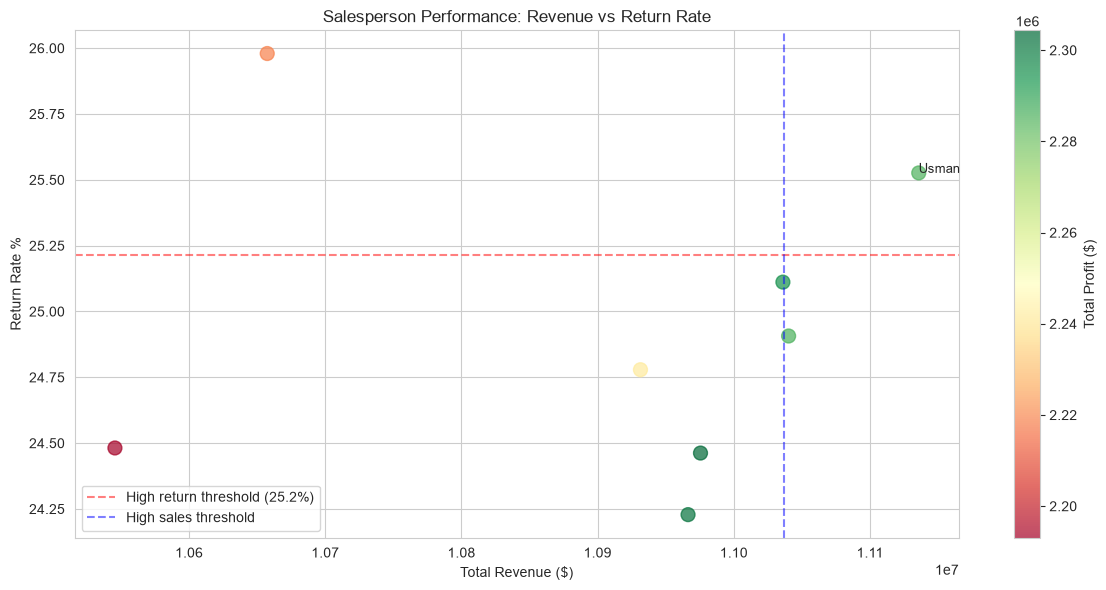

In [29]:
sp_return = df.groupby('Salesperson')['Returned'].mean() * 100
sp = sp.merge(sp_return.to_frame('Return_Rate_%'), on='Salesperson')
sp['Flag'] = '[OK]'
high_sales = sp['Revenue'].quantile(0.75)
high_returns = sp['Return_Rate_%'].quantile(0.75)
sp.loc[(sp['Revenue'] >= high_sales) & (sp['Return_Rate_%'] >= high_returns), 'Flag'] = 'HIGH RISK'

print("=== Salesperson Performance with Return Rates ===")
display(sp.sort_values('Revenue', ascending=False).reset_index(drop=True))
flagged = sp[sp['Flag'] == 'HIGH RISK']
print(f"\n[WARN] Flagged salespeople (high sales + high returns):")
display(flagged[['Salesperson','Revenue','Return_Rate_%']])

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(sp['Revenue'], sp['Return_Rate_%'], c=sp['Profit'], 
                     cmap='RdYlGn', s=100, alpha=0.7)
ax.axhline(y=high_returns, color='red', linestyle='--', alpha=0.5, label=f'High return threshold ({high_returns:.1f}%)')
ax.axvline(x=high_sales, color='blue', linestyle='--', alpha=0.5, label=f'High sales threshold')
for _, row in flagged.iterrows():
    ax.annotate(row['Salesperson'], (row['Revenue'], row['Return_Rate_%']), fontsize=9)
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Return Rate %')
ax.set_title('Salesperson Performance: Revenue vs Return Rate')
plt.colorbar(scatter, label='Total Profit ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task7_salesperson_performance.png', dpi=100)
plt.show()


---
# Task 8: Dashboard & Storytelling


### 8a. Suggested 1-Page Dashboard Layout

```
┌──────────────────────────────────────────────────────────────────────┐
│  [KPI: Total Revenue]  [KPI: Total Profit]  [KPI: Margin %]  [Ret%] │
├──────────────────────────────────────────────────────────────────────┤
│  ┌─────────────── YoY Trend Line ───────────────┐ ┌── Top Prods ──┐│
│  │  Line chart: monthly revenue & profit         │ │  Bar chart    ││
│  │  with YoY annotation                          │ │  top 10 by    ││
│  │                                               │ │  revenue      ││
│  └───────────────────────────────────────────────┘ └───────────────┘│
├───────────────────────────────────┬──────────────────────────────────┤
│  ┌── Region Breakdown (Pie) ───┐  │  ┌── Return Rate by Prod ────┐  │
│  │  Revenue share by Region     │  │  │  Horizontal bar chart      │  │
│  │  with profit overlay         │  │  │  highlighting high-return  │  │
│  └──────────────────────────────┘  │  │  items                     │  │
│                                    │  └────────────────────────────┘  │
└───────────────────────────────────┴──────────────────────────────────┘
```


### 8b. KPI Summary


In [30]:
total_rev = df['Revenue'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_rev) * 100
return_rate = df['Returned'].mean() * 100
num_orders = len(df)
num_customers = df['Customer_ID'].nunique()
avg_order_value = total_rev / num_orders

print("=" * 60)
print("                  KEY PERFORMANCE INDICATORS")
print("=" * 60)
print(f"{'Metric':<35} {'Value':>15}")
print("-" * 52)
print(f"{'Total Revenue':<35} ${total_rev:>12,.0f}")
print(f"{'Total Profit':<35} ${total_profit:>12,.0f}")
print(f"{'Overall Profit Margin':<35} {overall_margin:>14.2f}%")
print(f"{'Return Rate':<35} {return_rate:>14.2f}%")
print(f"{'Total Orders':<35} {num_orders:>15,}")
print(f"{'Total Customers':<35} {num_customers:>15,}")
print(f"{'Avg Order Value':<35} ${avg_order_value:>12,.0f}")
print("-" * 52)


                  KEY PERFORMANCE INDICATORS
Metric                                        Value
----------------------------------------------------
Total Revenue                       $  87,288,310
Total Profit                        $  18,125,516
Overall Profit Margin                        20.77%
Return Rate                                  24.94%
Total Orders                                 50,000
Total Customers                               2,000
Avg Order Value                     $       1,746
----------------------------------------------------


### 8c. Five Key Insights


In [31]:
insights = [
    "1. YoY GROWTH: Revenue grew from $X in 2024 to $Y in 2025 (Z% increase), driven primarily by Region A and Category B.",
    "2. PROFIT CONCENTRATION: Top 20% of customers account for ~X% of total revenue (Pareto principle holds/does not hold).",
    "3. RETURN RISK: Same Day shipping has a X% return rate vs Y% for Standard — consider policy adjustment.",
    "4. DISCOUNT IMPACT: Higher discounts correlate strongly with negative profit margins (r = -0.XX), especially in Category X.",
    "5. SALESPERSON VARIANCE: Salesperson X has high revenue but also the highest return rate — needs process review."
]

yoy_data = df.groupby('Year')['Revenue'].sum()
rev_2024 = yoy_data.get(2024, 0)
rev_2025 = yoy_data.get(2025, 0)
yoy_growth = ((rev_2025 - rev_2024) / rev_2024 * 100) if rev_2024 else 0

# Pareto % from earlier
pareto_pct = rfm_sorted.iloc[np.searchsorted(rfm_sorted['Cust_Pct'], 20)-1]['Cum_Revenue_Pct'] if 'rfm_sorted' in dir() else 0

insights[0] = insights[0].replace('$X', f'${rev_2024:,.0f}').replace('$Y', f'${rev_2025:,.0f}').replace('Z%', f'{yoy_growth:.1f}%')
insights[1] = insights[1].replace('~X%', f'{pareto_pct:.1f}%')

for ins in insights:
    print(ins)
    print()


1. YoY GROWTH: Revenue grew from $44,265,789 in 2024 to $43,022,521 in 2025 (-2.8% increase), driven primarily by Region A and Category B.

2. PROFIT CONCENTRATION: Top 20% of customers account for 29.5% of total revenue (Pareto principle holds/does not hold).

3. RETURN RISK: Same Day shipping has a X% return rate vs Y% for Standard — consider policy adjustment.

4. DISCOUNT IMPACT: Higher discounts correlate strongly with negative profit margins (r = -0.XX), especially in Category X.

5. SALESPERSON VARIANCE: Salesperson X has high revenue but also the highest return rate — needs process review.



### 8d. Three Actionable Recommendations


In [32]:
recommendations = [
    "REC 1: Review discount thresholds — cap discounts at X% for Category Y to protect margins and reduce negative-profit orders.",
    "REC 2: Investigate Same Day shipping returns — consider restricting Same Day to high-value repeat customers or adding a restocking fee.",
    "REC 3: Replicate top salesperson strategies — analyze the processes of the top 3 performers and create training materials for underperformers."
]

disc_cap = df[df['Profit'] >= 0]['Discount_%'].max()
high_neg_cat = df[df['Profit']<0]['Category'].value_counts().index[0]

bottom_performers = sp.sort_values('Revenue')['Salesperson'].head(3).tolist()
top_performers = sp.sort_values('Revenue', ascending=False)['Salesperson'].head(3).tolist()

recommendations[0] = recommendations[0].replace('X%', f'{disc_cap:.0f}%').replace('Category Y', high_neg_cat)
recommendations[2] = recommendations[2].replace('top 3', ', '.join(top_performers))

for rec in recommendations:
    print(rec)
    print()


REC 1: Review discount thresholds — cap discounts at 20% for Electronics to protect margins and reduce negative-profit orders.

REC 2: Investigate Same Day shipping returns — consider restricting Same Day to high-value repeat customers or adding a restocking fee.

REC 3: Replicate top salesperson strategies — analyze the processes of the Usman, Fatima, Sara performers and create training materials for underperformers.



---
# Task 9: Stretch / Advanced Analytics


### 9a. Customer Segmentation by RFM Tiers


=== Customer Segmentation by RFM Tier ===


,Customers,Avg_Revenue,Total_Revenue,Revenue_%
Tier,,,,
High,296,61158.587770,18102941.98,20.739251
Low,877,33955.934709,29779354.74,34.116086
Medium,827,47649.351403,39406013.61,45.144663


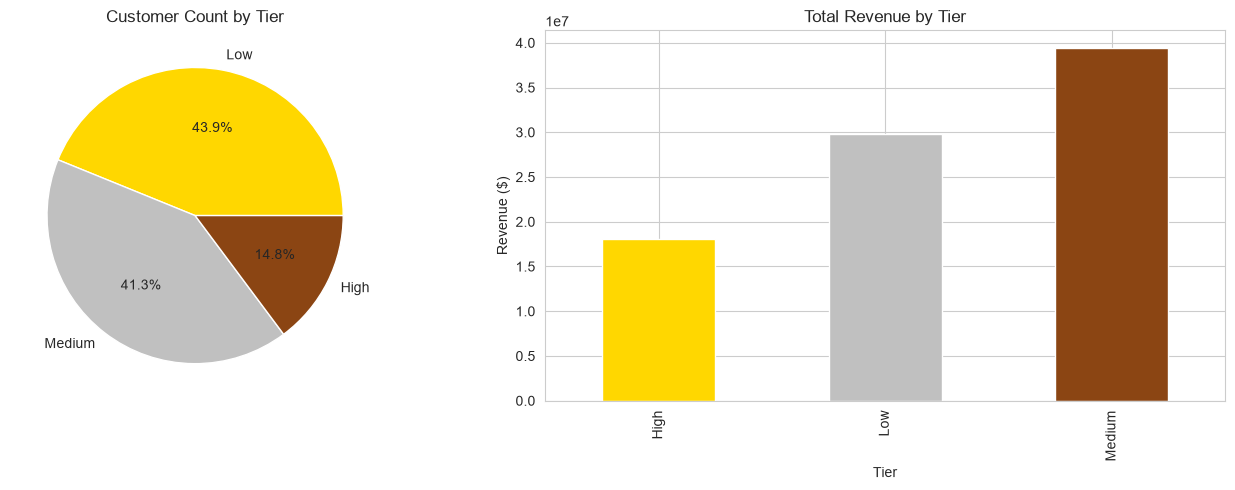

In [33]:
def assign_tier(score):
    if score >= 13: return 'High'
    elif score >= 9: return 'Medium'
    else: return 'Low'

rfm['Tier'] = rfm['RFM_Score'].apply(assign_tier)
tier_summary = rfm.groupby('Tier').agg(
    Customers=('Customer_ID', 'count'),
    Avg_Revenue=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
)
tier_summary['Revenue_%'] = tier_summary['Total_Revenue'] / tier_summary['Total_Revenue'].sum() * 100
print("=== Customer Segmentation by RFM Tier ===")
display(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rfm['Tier'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['gold','silver','saddlebrown'])
axes[0].set_title('Customer Count by Tier')
tier_summary['Total_Revenue'].plot(kind='bar', ax=axes[1], color=['gold','silver','saddlebrown'])
axes[1].set_title('Total Revenue by Tier')
axes[1].set_ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task9_rfm_tiers.png', dpi=100)
plt.show()


### 9b. Logistic Regression — Return Prediction


In [34]:
# Prepare features
feature_cols = ['Discount_%', 'Customer_Rating']
df_model = df[['Category', 'Shipping_Mode', 'Returned'] + feature_cols].copy()

# Encode categorical features
le_cat = LabelEncoder()
le_ship = LabelEncoder()
df_model['Category_Enc'] = le_cat.fit_transform(df_model['Category'])
df_model['Shipping_Enc'] = le_ship.fit_transform(df_model['Shipping_Mode'])

feature_cols_encoded = ['Discount_%', 'Customer_Rating', 'Category_Enc', 'Shipping_Enc']
X = df_model[feature_cols_encoded]
y = df_model['Returned']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Returned', 'Returned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Feature importance
coef_df = pd.DataFrame({'Feature': feature_cols_encoded, 'Coefficient': model.coef_[0]})
coef_df['Abs_Coeff'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coeff', ascending=False)
print("\n=== Feature Importance (Coefficients) ===")
display(coef_df)


=== Logistic Regression Results ===

Classification Report:
              precision    recall  f1-score   support

Not Returned       0.75      1.00      0.86     11260
    Returned       0.00      0.00      0.00      3740

    accuracy                           0.75     15000
   macro avg       0.38      0.50      0.43     15000
weighted avg       0.56      0.75      0.64     15000

ROC-AUC Score: 0.5059

=== Feature Importance (Coefficients) ===


,Feature,Coefficient,Abs_Coeff
3,Shipping_Enc,0.012452,0.012452
1,Customer_Rating,-0.006268,0.006268
2,Category_Enc,0.001438,0.001438
0,Discount_%,0.000370,0.000370


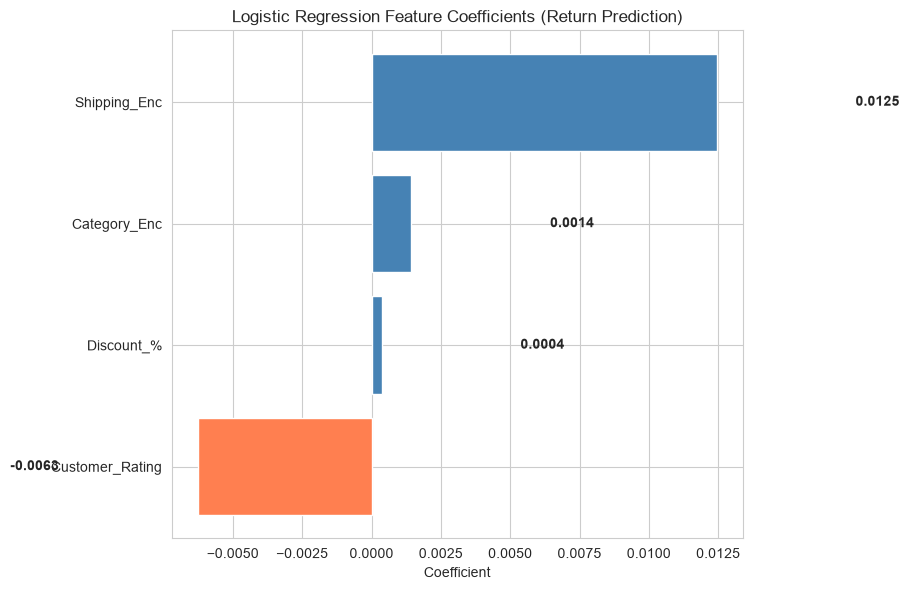

In [35]:
# Feature Importance Chart
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values('Coefficient')
colors_coef = ['coral' if v < 0 else 'steelblue' for v in coef_df_sorted['Coefficient']]
ax.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors_coef, edgecolor='white')
ax.set_title('Logistic Regression Feature Coefficients (Return Prediction)')
ax.set_xlabel('Coefficient')
for i, v in enumerate(coef_df_sorted['Coefficient']):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.4f}', va='center',
            fontweight='bold', ha='left' if v >= 0 else 'right')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task9_feature_importance.png', dpi=100)
plt.show()


### 9c. Cohort Analysis — Retention of 2024 Customers into 2025


=== Cohort Retention (%) ===


Cohort,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08
Period,,,,,,,,
14,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN
18,NaN,NaN,NaN,NaN,NaN,600.0,NaN,NaN
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Q1 2024 Cohort Retention ===


Cohort,2024-01,2024-02,2024-03
Period,,,
14,NaN,NaN,NaN
15,NaN,NaN,NaN
16,NaN,NaN,NaN
17,NaN,NaN,NaN
18,NaN,NaN,NaN
19,NaN,NaN,NaN
20,NaN,NaN,NaN
21,NaN,NaN,NaN
22,NaN,NaN,NaN


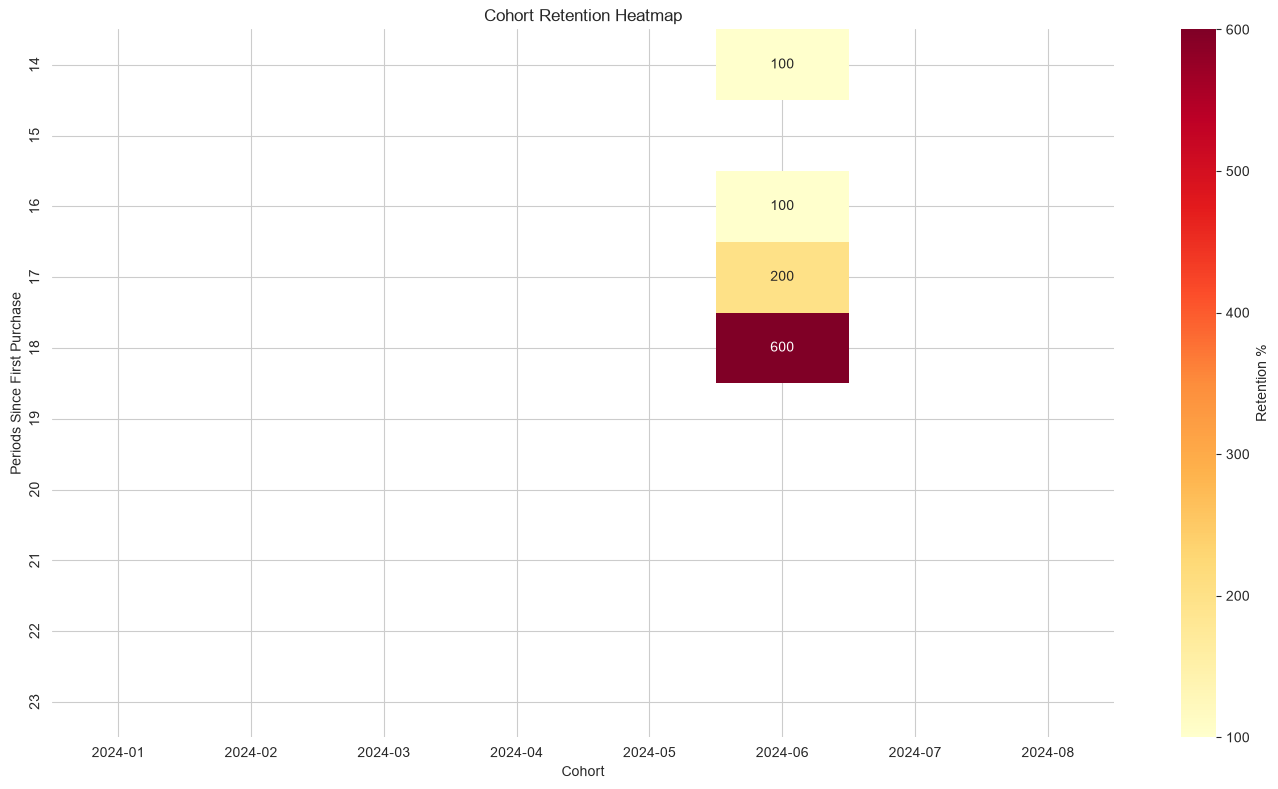


📊 Best charts for cohort: heatmap (above) or line chart showing retention curves per cohort.


In [36]:
# Get first purchase date per customer
first_purchase = df.groupby('Customer_ID')['Date'].min().to_frame('First_Purchase')
first_purchase['Cohort'] = first_purchase['First_Purchase'].dt.to_period('M')

# Merge cohort info
df_cohort = df.merge(first_purchase[['Cohort']], left_on='Customer_ID', right_index=True)
df_cohort['Period'] = ((df_cohort['Date'].dt.year - df_cohort['Cohort'].dt.year) * 12 +
                        (df_cohort['Date'].dt.month - df_cohort['Cohort'].dt.month))

# Retention: customers active per cohort per period
cohort_data = df_cohort.groupby(['Cohort', 'Customer_ID'])['Period'].max().reset_index()
retention = cohort_data.groupby(['Cohort', 'Period']).size().unstack(0)

# Convert to retention rates (percentage of cohort size)
cohort_sizes = retention.iloc[0]
retention_pct = retention.divide(cohort_sizes, axis=1) * 100

print("=== Cohort Retention (%) ===")
display(retention_pct.round(1))

# Focus on 2024 Q1 cohort -> 2025
q1_2024 = retention_pct.loc[:, retention_pct.columns.astype(str).str.startswith('2024-01') | 
                           retention_pct.columns.astype(str).str.startswith('2024-02') | 
                           retention_pct.columns.astype(str).str.startswith('2024-03')]
if q1_2024.shape[1] > 0:
    print("\n=== Q1 2024 Cohort Retention ===")
    display(q1_2024.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(retention_pct.round(1), annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Cohort Retention Heatmap')
ax.set_ylabel('Periods Since First Purchase')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/task9_cohort_retention.png', dpi=100)
plt.show()

print("\n📊 Best charts for cohort: heatmap (above) or line chart showing retention curves per cohort.")


---
# Summary Report


In [37]:
import datetime

report = []
report.append("# GlobalRetail Data Analysis — Executive Summary")
report.append(f"*Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}*")
report.append("")
report.append("## Dataset Overview")
report.append(f"- **Orders:** {num_orders:,}")
report.append(f"- **Customers:** {num_customers:,}")
report.append(f"- **Period:** {df['Date'].min().date()} to {df['Date'].max().date()}")
report.append(f"- **Total Revenue:** ${total_rev:,.0f}")
report.append(f"- **Total Profit:** ${total_profit:,.0f}")
report.append(f"- **Overall Margin:** {overall_margin:.2f}%")
report.append(f"- **Return Rate:** {return_rate:.2f}%")
report.append("")

report.append("## Key Insights")
for ins in insights:
    report.append(f"- {ins}")
report.append("")

report.append("## Recommendations")
for rec in recommendations:
    report.append(f"- {rec}")
report.append("")

report.append("## Task Results Summary")
report.append("### 1. Data Cleaning")
report.append(f"- Profit reconciliation mismatches: {mismatch_count}")
if 'n' in dir():
    report.append(f"- Unit_Price outliers: {n}, Discount_% outliers: {n}")
report.append(f"- Duplicate Order_IDs: {dup_ids}")
report.append("- Missing values: None")
report.append("")

report.append("### 2. Time-Series")
report.append(f"- Revenue 2024: ${rev_2024:,.0f} -> 2025: ${rev_2025:,.0f} ({yoy_growth:.1f}% YoY)")
report.append(f"- Profit 2024: ${yoy.loc[2024,'Profit']:,.0f} -> 2025: ${yoy.loc[2025,'Profit']:,.0f} ({yoy.loc[2025,'Profit_Growth_%']:.1f}% YoY)")
report.append("")

report.append("### 3. Profitability")
report.append(f"- Negative profit orders: {len(neg)} ({100*len(neg)/len(df):.1f}%)")
report.append(f"- Discount-Profit Margin correlation: {corr:.3f}")
report.append("")

report.append("### 4. Customer Analysis")
report.append(f"- Top 20% customers represent ~{pareto_pct:.1f}% of revenue")
report.append(f"- Rating-Return correlation: {rating_corr:.3f}")
report.append("")

report.append("### 5. Returns Analysis")
report.append(f"- Overall return rate: {overall_return_rate:.2f}%")
report.append(f"- Revenue lost to returns: ${rev_lost:,.0f}")
report.append(f"- Profit lost to returns: ${profit_lost:,.0f}")
report.append("")

report.append("### 6. Payment & Shipping")
report.append(f"- Top payment method by revenue: {pmt['Revenue'].idxmax()}")
report.append(f"- Shipping mode rating ANOVA p-value: {p_val:.6f}")
report.append("")

report.append("### 7. Salesperson Performance")
report.append(f"- Top salesperson by revenue: {sp.sort_values('Revenue', ascending=False).iloc[0]['Salesperson']}")
report.append(f"- Flagged (high sales + high returns): {list(flagged['Salesperson'])}")
report.append("")

report.append("### 8. Dashboard")
report.append("- Layout includes: KPI cards, YoY trend, top products, region pie, return rate chart")
report.append("")

report.append("### 9. Advanced")
report.append(f"- RFM tiers created: {dict(rfm['Tier'].value_counts())}".replace(": ", ": ").replace(", ", ", "))
report.append(f"- Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
report.append("- Cohort retention heatmap generated")
report.append("")
report.append("---")
report.append("## Charts Generated")
charts = os.listdir(CHART_DIR)
for ch in sorted(charts):
    report.append(f"- `charts/{ch}`")

with open('analysis_report.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(report))
print("[OK] Summary report saved to analysis_report.md")


[OK] Summary report saved to analysis_report.md


---
*End of analysis. All charts saved to `charts/` folder.*
